## Import

In [2]:
from pathlib import Path
import pandas as pd
import os
import numpy as np
from tqdm import tqdm
from xml.etree.ElementTree import fromstring, ElementTree
from Evtx.Evtx import Evtx
import csv

In [3]:
%load_ext autoreload
%autoreload 2
import preprocess
import main
import a
from unmask_attributes import process_csv
import embedding_converter
import train_score_bert
import test_score_bert
import test_score_bert_v1
import diagnosis
import diagnosis_v1

/home/ubuntu/My_lad/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
INTERIM_DIR = Path('../data/interim')
PROCESSED_DIR = Path('../data/processed')
RAW_DIR = Path('../data/raw')
NO_MEANING_DIR = Path('../data/no_meaning')
PROJECT_ROOT = Path("../")

# データ作成

## refine データ作成
- securityログ
- T1105, (VSCode1), WEB1, WEB2　を含む（12/28時点ではWEB2のアノマリーは含まず）
- integrated を流用

In [ ]:
df = pd.read_csv(INTERIM_DIR/"Integrated/security2_structured.csv") 

In [5]:
cond = (df["Label"] == "anomaly") & (df["project"] == "WEB2")

idx = df.index[cond]
if len(idx) > 0:
    df = df.loc[:idx[0]-1]
    
df.loc[df["project"] == "WEB2", "project"] = "WEB2_C"
df.to_csv(INTERIM_DIR/"refine/security2_structured.csv")

# 検証

## Windows（LogBERT）

### 素

In [ ]:
preprocess.prepare_refine_model_data(
    logdata_filepath = INTERIM_DIR/"refine/security2_structured.csv",
    output_dir = PROCESSED_DIR/"refine_time",
    window_size = 1800, # 30min
    step_size = 900,
    mode = "time",
)

/home/siwamura/My_lad/src/preprocess.py:1006: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 3154 instances (sliding windows) in this dataset

there are 864 instances (sliding windows) in this dataset

there are 1100 instances (sliding windows) in this dataset

there are 805 instances (sliding windows) in this dataset

Project info saved to ../data/processed/refine_time/ratio_0.8/train_projects.csv
Project info saved to ../data/processed/refine_time/ratio_0.8/test_normal_projects.csv
Project info saved to ../data/processed/refine_time/ratio_0.8/test_abnormal_projects.csv
Project info saved to ../data/processed/refine_time/vocab/train_projects.csv
vocab size 5620
Sequence Length Statistics Report
Generated: 2025-12-21 21:57:25
Mode: time
Window Size: 1800
Step Size: 900

[Ratio: 0.8]
--------------------------------------------------
  train:
    Count:    4,496
    Avg Len:  461.97
    Min Len:  97
    Max Len:  22258
    Std Dev:  479.56
  test_normal:
    Count:    1,124
    Avg Len:  481.16
    Min Len:  5
    Max Len:  21798
    Std Dev:  725.68
  test_abnormal:


In [11]:
preprocess.prepare_refine_model_data(
    logdata_filepath = INTERIM_DIR/"refine/security2_structured.csv",
    output_dir = PROCESSED_DIR/"refine_fixed",
    window_size = 430, # 時間ベースの分割における平均値を採用(サンプル数が5000前後になるように調整)
    step_size = 200,
    mode = "fixed",
)

/home/ubuntu/My_lad/src/preprocess.py:1174: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 4248 instances (sliding windows) in this dataset

there are 887 instances (sliding windows) in this dataset

there are 969 instances (sliding windows) in this dataset

there are 720 instances (sliding windows) in this dataset

Project info saved to ../data/processed/refine_fixed/train_projects.csv
Project info saved to ../data/processed/refine_fixed/test_normal_projects.csv
Project info saved to ../data/processed/refine_fixed/test_abnormal_projects.csv
Project info saved to ../data/processed/refine_fixed/vocab/train_projects.csv
vocab size 6573
Sequence Length Statistics Report
Generated: 2026-01-12 20:26:31
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: 0.8]
--------------------------------------------------
  train:
    Count:    5,258
    Avg Len:  430.00
    Min Len:  430
    Max Len:  430
    Std Dev:  0.00
  test_normal:
    Count:    1,315
    Avg Len:  430.00
    Min Len:  430
    Max Len:  430
    Std Dev:  0.00
  test_abnormal:
    Count:    251
    Avg Len:  

### unmask & MD5

In [4]:
process_csv(
    input_csv_path=INTERIM_DIR/'refine/security2_structured.csv',
    output_csv_path=INTERIM_DIR/'refine/security2_structured_unmasked.csv',
    no_mask_config="no_mask.json",
    new_column_name='EventTemplateUnmasked',
    hash_method="md5",
)

Loading no_mask config from: no_mask.json
Loading CSV from: ../data/interim/refine/security2_structured.csv
Total rows: 1366109
Columns: ['LineId', 'Level', 'EventID', 'EventRecordID', 'TimeCreated_SystemTime', 'Channel', 'Task', 'Provider_Name', 'Correlation_RelatedActivityID', 'Execution_ProcessID', 'Execution_ThreadID', 'Security_UserID', 'Keywords', 'Content', 'Correlation_ActivityID', 'Provider_Guid', 'Computer', 'Opcode', 'Version', 'Label', 'date', 'project', 'EventId', 'EventTemplate']

Processing EventID: 4688, Attributes: ['ProcessId']
  Found 39423 rows with EventID=4688

Processing EventID: 5156, Attributes: ['ProcessID']
  Found 685614 rows with EventID=5156

Generating MD5 hash column: EventTemplateUnmaskedHash_md5
  Hash column created with 1366109 values (MD5)

Saving result to: ../data/interim/refine/security2_structured_unmasked.csv
Done!

--- Sample of unmasked data ---

EventID 4688:
  Original: SubjectUserSid=<*>|SubjectUserName=<*>|SubjectDomainName=<*>|SubjectLog

In [12]:
preprocess.prepare_refine_model_data(
    logdata_filepath = INTERIM_DIR/"refine/security2_structured_unmasked.csv",
    output_dir = PROCESSED_DIR/"refine2/fixed",
    event_id="EventTemplateUnmaskedHash_md5",
    features = ["EventTemplateUnmaskedHash_md5", "deltaT"],
    use_columns = ["timestamp", "Label", "EventID", "EventTemplateUnmaskedHash_md5", "deltaT"],
    window_size = 430,
    step_size = 200,
    mode = "fixed",
)

/home/ubuntu/My_lad/src/preprocess.py:1174: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 4248 instances (sliding windows) in this dataset

there are 887 instances (sliding windows) in this dataset

there are 969 instances (sliding windows) in this dataset

there are 720 instances (sliding windows) in this dataset

Project info saved to ../data/processed/refine2/fixed/train_projects.csv
Project info saved to ../data/processed/refine2/fixed/test_normal_projects.csv
Project info saved to ../data/processed/refine2/fixed/test_abnormal_projects.csv
Project info saved to ../data/processed/refine2/fixed/vocab/train_projects.csv
vocab size 6573
Sequence Length Statistics Report
Generated: 2026-01-12 20:27:32
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: 0.8]
--------------------------------------------------
  train:
    Count:    5,258
    Avg Len:  430.00
    Min Len:  430
    Max Len:  430
    Std Dev:  0.00
  test_normal:
    Count:    1,315
    Avg Len:  430.00
    Min Len:  430
    Max Len:  430
    Std Dev:  0.00
  test_abnormal:
    Count:    251
    Avg Le

In [8]:
preprocess.shuffle_elements_per_row(
    input_dir=Path("../data/processed/refine2/fixed"),
    output_dir=Path("../data/processed/refine2/shuffled"),
    random_seed=31,
)

Processing: ../data/processed/refine2/fixed/test_abnormal


Shuffling test_abnormal: 251it [00:00, 3006.76it/s]


  Processed 251 lines -> ../data/processed/refine2/shuffled/test_abnormal
Processing: ../data/processed/refine2/fixed/test_normal


Shuffling test_normal: 1315it [00:00, 4817.83it/s]


  Processed 1315 lines -> ../data/processed/refine2/shuffled/test_normal
Processing: ../data/processed/refine2/fixed/train


Shuffling train: 5258it [00:00, 6209.15it/s]


  Processed 5258 lines -> ../data/processed/refine2/shuffled/train

Shuffle complete. Output saved to: ../data/processed/refine2/shuffled


### unmask & LSH

In [15]:
process_csv(
    input_csv_path=INTERIM_DIR/'refine/security2_structured.csv',
    output_csv_path=INTERIM_DIR/'refine/security2_structured_unmasked.csv',
    no_mask_config="no_mask.json",
    new_column_name='EventTemplateUnmasked',
    hash_method="lsh",
    use_multiprocess=True
)


Loading no_mask config from: no_mask.json
Loading CSV from: ../data/interim/refine/security2_structured.csv
Total rows: 1366109
Columns: ['LineId', 'Level', 'EventID', 'EventRecordID', 'TimeCreated_SystemTime', 'Channel', 'Task', 'Provider_Name', 'Correlation_RelatedActivityID', 'Execution_ProcessID', 'Execution_ThreadID', 'Security_UserID', 'Keywords', 'Content', 'Correlation_ActivityID', 'Provider_Guid', 'Computer', 'Opcode', 'Version', 'Label', 'date', 'project', 'EventId', 'EventTemplate']

Processing EventID: 4688, Attributes: ['SubjectUserSid', 'NewProcessName', 'CommandLine']
  Found 39423 rows with EventID=4688

Processing EventID: 5156, Attributes: ['Application', 'DestPort']
  Found 685614 rows with EventID=5156

Generating LSH (GPU) hash column: EventTemplateUnmaskedHash_lsh
  GPU LSH Progress: 100000/1366109 (7.3%)
  GPU LSH Progress: 200000/1366109 (14.6%)
  GPU LSH Progress: 300000/1366109 (22.0%)
  GPU LSH Progress: 400000/1366109 (29.3%)
  GPU LSH Progress: 500000/13661

In [16]:
preprocess.prepare_refine_model_data(
    logdata_filepath = INTERIM_DIR/"refine/security2_structured_unmasked.csv",
    output_dir = PROCESSED_DIR/"refine2/fixed",
    event_id="EventTemplateUnmaskedHash_lsh",
    features = ["EventTemplateUnmaskedHash_lsh", "deltaT"],
    use_columns = ["timestamp", "Label", "EventID", "EventTemplateUnmaskedHash_lsh", "deltaT"],
    window_size = 430,
    step_size = 200,
    mode = "fixed",
)

/home/ubuntu/My_lad/src/preprocess.py:1008: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 4248 instances (sliding windows) in this dataset

there are 887 instances (sliding windows) in this dataset

there are 969 instances (sliding windows) in this dataset

there are 720 instances (sliding windows) in this dataset

Project info saved to ../data/processed/refine2/fixed/train_projects.csv
Project info saved to ../data/processed/refine2/fixed/test_normal_projects.csv
Project info saved to ../data/processed/refine2/fixed/test_abnormal_projects.csv
Project info saved to ../data/processed/refine2/fixed/vocab/train_projects.csv
vocab size 6573
Sequence Length Statistics Report
Generated: 2025-12-31 16:30:54
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: 0.8]
--------------------------------------------------
  train:
    Count:    5,258
    Avg Len:  430.00
    Min Len:  430
    Max Len:  430
    Std Dev:  0.00
  test_normal:
    Count:    1,315
    Avg Len:  430.00
    Min Len:  430
    Max Len:  430
    Std Dev:  0.00
  test_abnormal:
    Count:    251
    Avg Le

### テスト実行部

In [6]:
# train
main.main_cli([
    "train",
    "bert/refine2_",          # conf/bert_config_name.yaml
    #"default.device_id=0",        # ここに好きな key=value を並べる
    #"default.epochs=10",
])

setup
Building Vocab


100%|██████████| 5258/5258 [00:00<00:00, 17815.16it/s]


VOCAB SIZE: 3806
DEBUG suggest_dataloader: cfg.dataset.vocab.vocab_size = None (type: <class 'str'>)
Updating vocab_size from None to 3806
After update: cfg.dataset.vocab.vocab_size = 3806
before filtering short session
train size  4733
valid size  525


100%|██████████| 5258/5258 [00:02<00:00, 2199.43it/s]


Num of train seqs 4733
Num of valid seqs 525
DEBUG main.py: cfg.dataset.vocab.vocab_size = 3806 (type: <class 'int'>)


...

epoch 9 || TRAIN_Loss:2.8332 ||VAL_Loss:2.7243
Best epoch = 9


147it [00:04, 33.99it/s]
16it [00:00, 95.82it/s]


epoch 10 || TRAIN_Loss:2.8104 ||VAL_Loss:2.7092
Best epoch = 10


137it [00:04, 31.07it/s]


KeyboardInterrupt: 

In [5]:
# テスト
main.main_cli([
    "test",  # run_mode
    "../outputs/logbert/bert_no_time/refine2/fixed/seq_len_512/r_seed_31/weights/ValTotalbest.pth", # 重みファイルまでの相対パス
    "32",   # eval_batchsize
    "cuda:0",     # gpu
    "eval.dataset_dir: ../data/processed/refine2/fixed"
])

../outputs/logbert/bert_no_time/refine2/fixed/seq_len_512/r_seed_31
cuda:0 cuda:0
Building Vocab


100%|██████████| 251/251 [00:00<00:00, 5589.91it/s]


VOCAB SIZE: 26985
Updated vocab_size to 26985


100%|██████████| 251/251 [00:01<00:00, 160.08it/s]

Saving test normal results
Saving test abnormal results
[seq_th, FP, TP, TN, FN, Precision, Recall, F1, TPR, FPR]
threshold=0.000['0.0000', '0.0000', '1312.0000', '251.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000']
threshold=0.100['0.0000', '0.0000', '1312.0000', '251.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000']
threshold=0.200['0.0000', '0.0000', '1312.0000', '251.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000']
threshold=0.300['0.0000', '0.0000', '1312.0000', '251.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000']
threshold=0.400['0.0000', '0.0000', '1312.0000', '251.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000']
threshold=0.500['0.0000', '0.0000', '1312.0000', '251.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000']
threshold=0.600['0.0000', '0.0000', '1312.0000', '251.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000']
threshold=0.700['0.0000', '0.0000', '1312.0000', '251.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000'

In [ ]:
# train
main.main_cli([
    "train",
    "bert/refine2",           # conf/bert_config_name.yaml
    #"default.device_id=0",        # ここに好きな key=value を並べる
    #"default.epochs=10",
])

### 可視化（archive参照）：

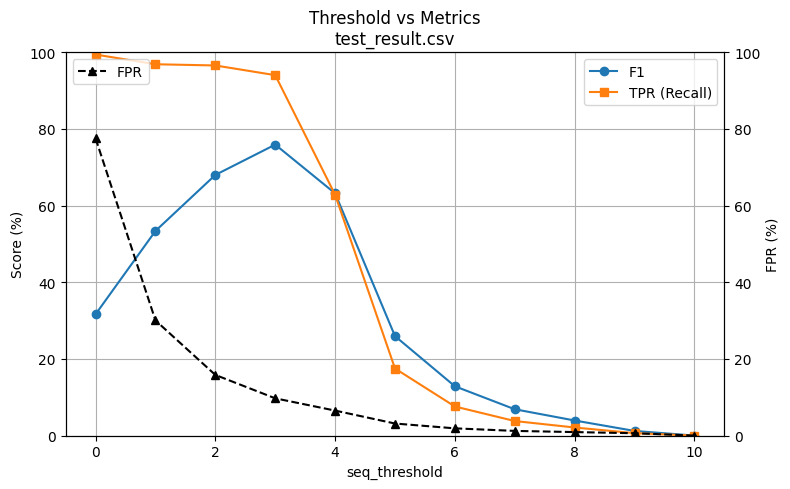

In [6]:
a.plot_threshold_metrics(Path("../archive/10/refine2/fixed/seq_len_512/r_seed_31/test_result.csv"))

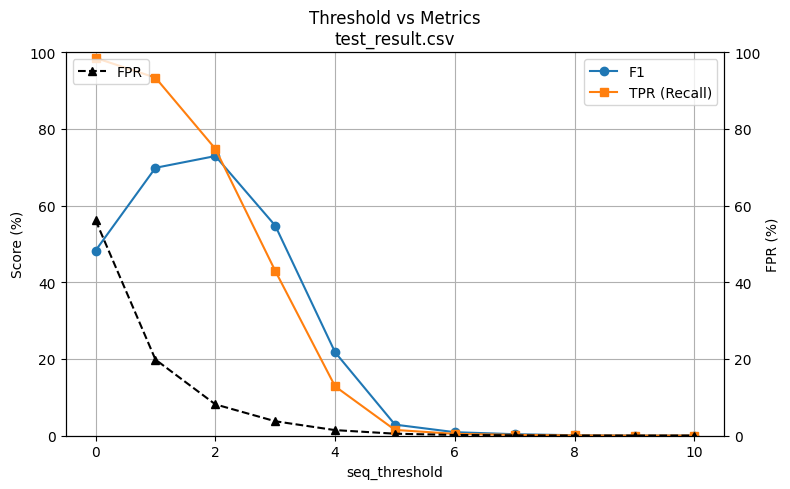

In [17]:
a.plot_threshold_metrics(Path("../archive/9/refine2/time/seq_len_512/r_seed_31/test_result.csv"))

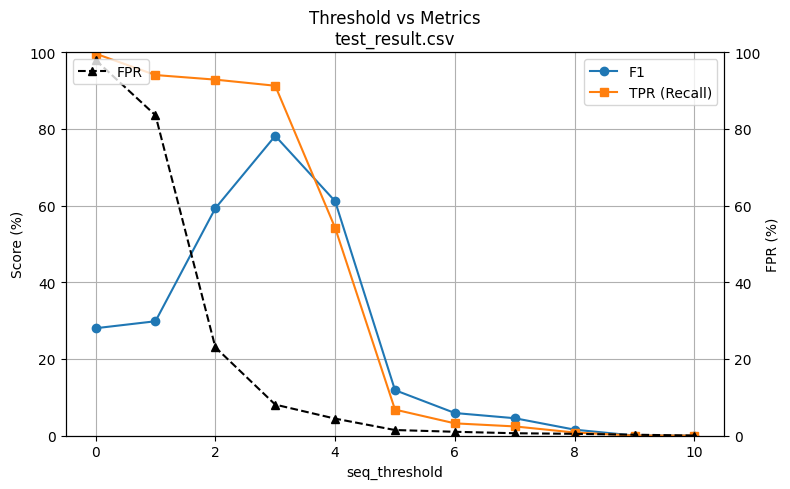

In [12]:
a.plot_threshold_metrics(Path("../archive/8/refine2/fixed/seq_len_512/r_seed_31/test_result.csv"))

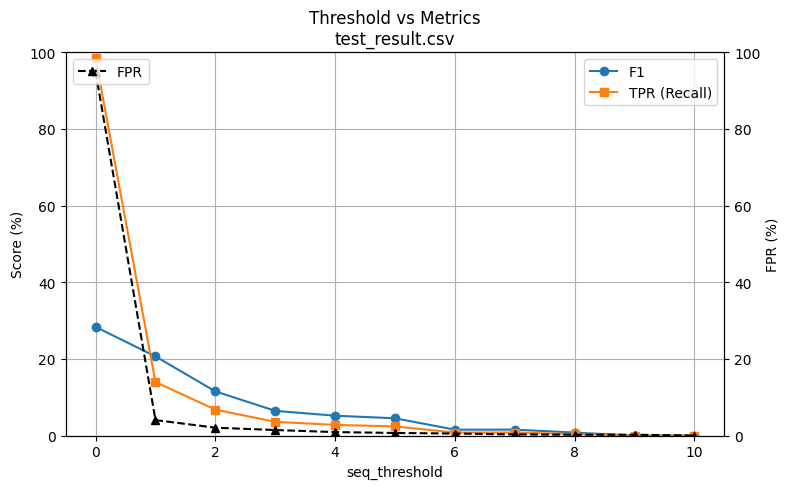

In [12]:
a.plot_threshold_metrics(Path("../archive/7/refine2/fixed/seq_len_512/r_seed_31/test_result.csv"))

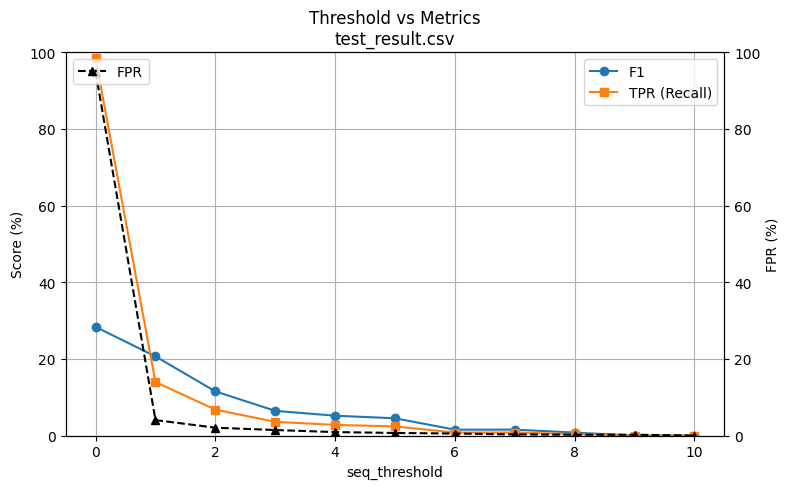

In [7]:
a.plot_threshold_metrics(Path("../archive/6/refine2/fixed/seq_len_512/r_seed_31/test_result.csv"))

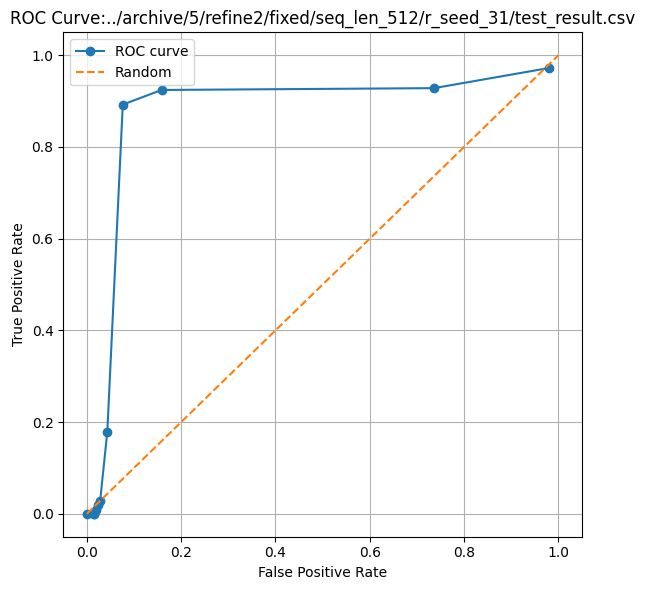

In [8]:
a.plot_roc(Path("../archive/5/refine2/fixed/seq_len_512/r_seed_31/test_result.csv"))

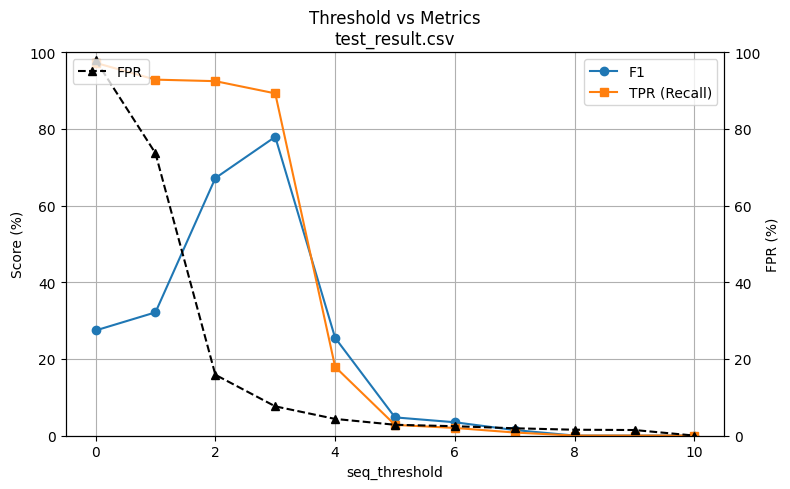

In [5]:
a.plot_threshold_metrics(Path("../archive/5/refine2/fixed/seq_len_512/r_seed_31/test_result.csv"))

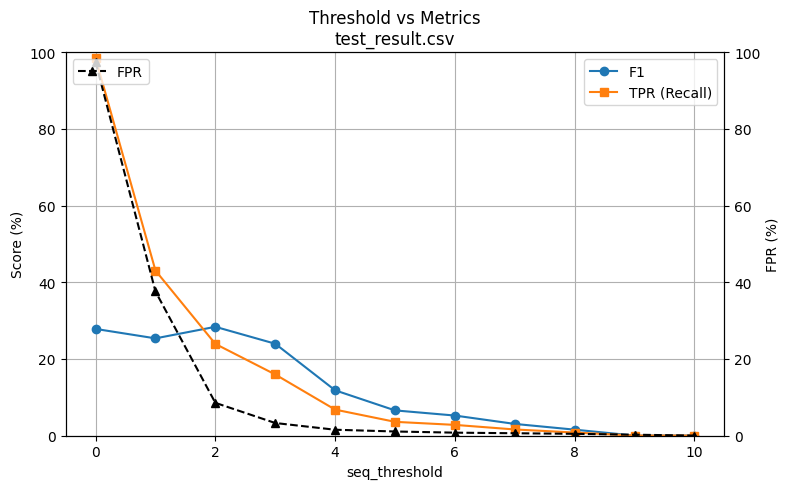

In [19]:
a.plot_threshold_metrics(Path("../archive/4/refine2/fixed/seq_len_512/r_seed_31/test_result.csv"))

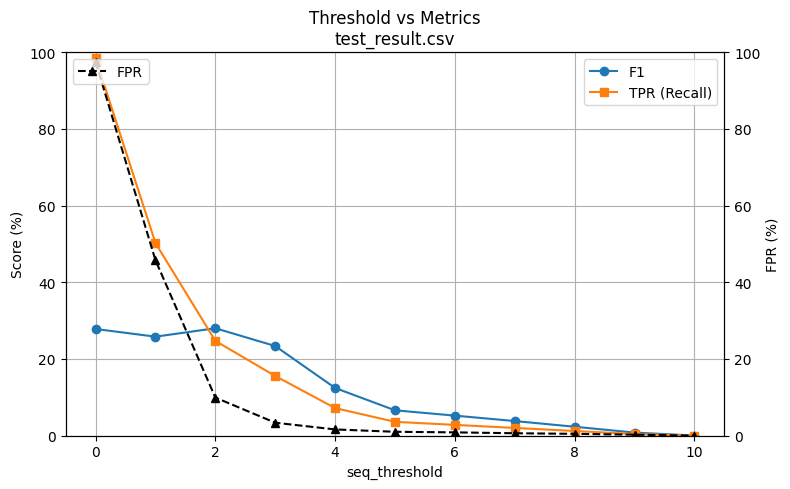

In [14]:
a.plot_threshold_metrics(Path("../archive/3/refine2/fixed/seq_len_512/r_seed_31/test_result.csv"))

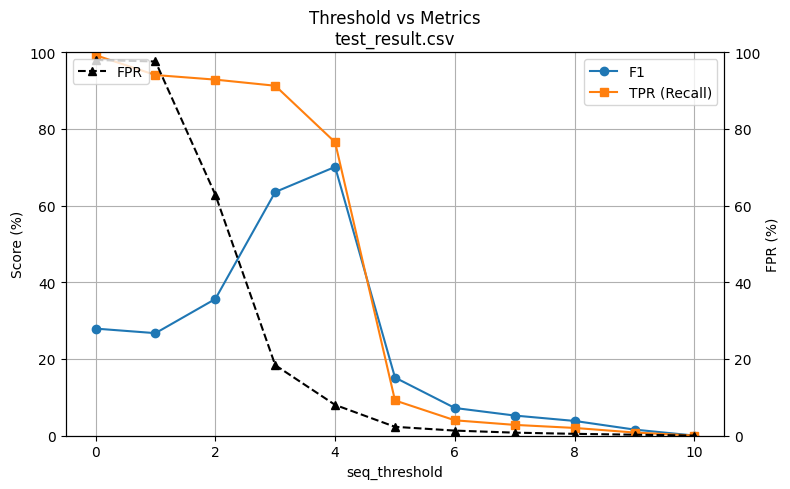

In [9]:
a.plot_threshold_metrics(Path("../archive/2/refine2/fixed/seq_len_512/r_seed_31/test_result.csv"))

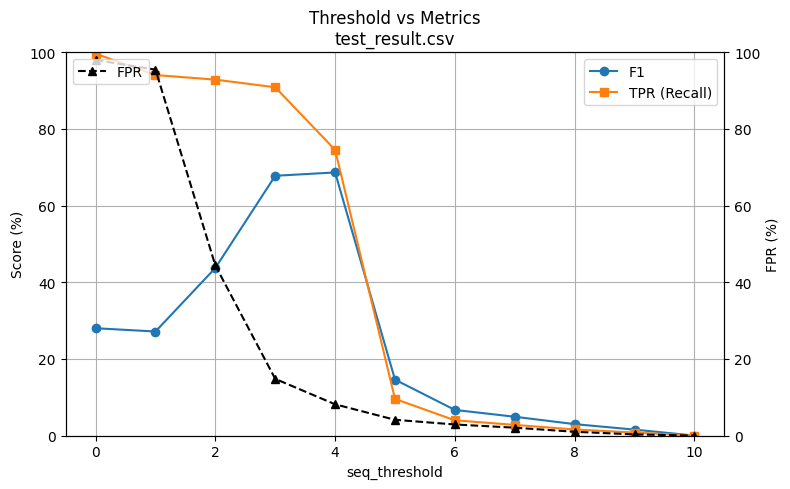

In [9]:
a.plot_threshold_metrics(Path("../archive/1/refine2/fixed/seq_len_512/r_seed_31/test_result.csv"))

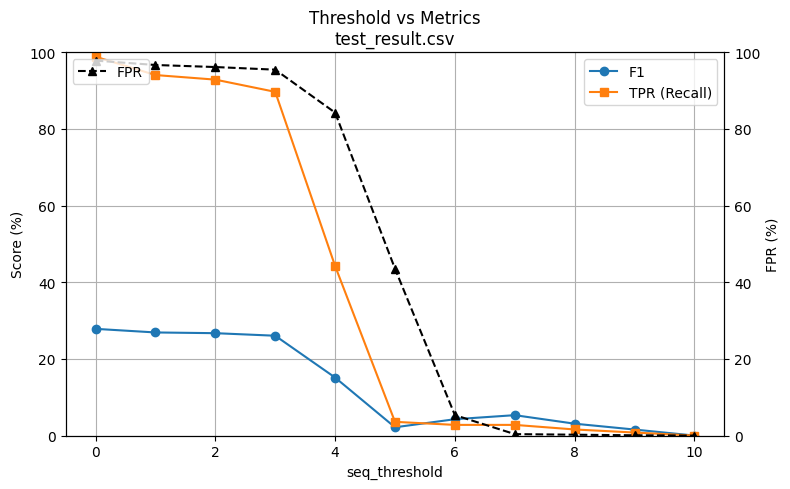

In [ ]:
a.plot_threshold_metrics(Path("../archive/0/refine2/fixed/seq_len_512/r_seed_31/test_result.csv"))

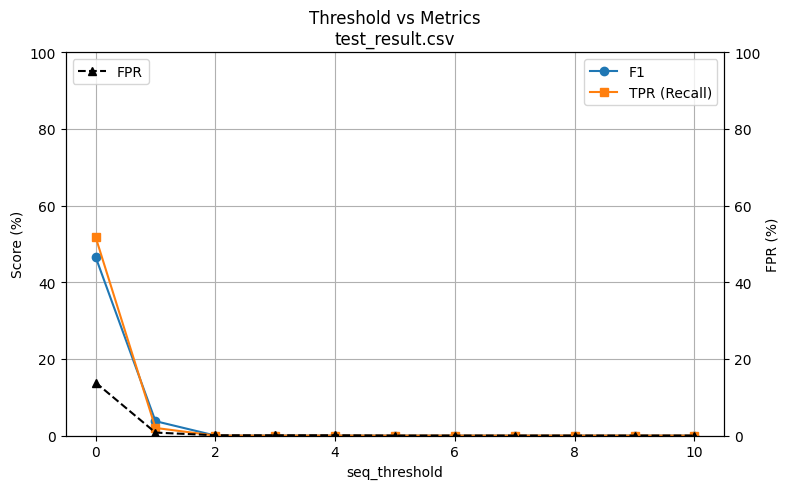

In [8]:
a.plot_threshold_metrics(Path("../output/logbert/bert/refine/fixed/seq_len_512/r_seed_31/test_result.csv"))

## BGL

In [ ]:
preprocess.prepare_bgl_model_data(
    logdata_filepath = INTERIM_DIR/"BGL/BGL_structured.csv",
    output_dir = PROCESSED_DIR/"BGL",
    window_size = 300, # 時間ベースの分割における平均値を採用
    step_size = 60,
    mode = "time",
)

In [17]:
preprocess.extract_line(
    input_file=Path(PROCESSED_DIR/"BGL/ratio_0.8/train_full"),
    output_file=Path(PROCESSED_DIR/"BGL/ratio_0.8/train")
)

In [ ]:
# train
main.main_cli([
    "train",
    "bert/bgl",           # conf/bert_config_name.yaml
    #"default.device_id=0",        # ここに好きな key=value を並べる
    #"default.epochs=10",
])

In [12]:
# テスト
main.main_cli([
    "test",  # run_mode
    "outputs/logbert/bert/BGL/fixed/seq_len_512/r_seed_31/weights/ValTotalbest.pth", # 重みファイルまでの相対パス
    "64",   # eval_batchsize
    "cuda:0",     # gpu
])

outputs/logbert/bert/BGL/fixed/seq_len_512/r_seed_31
cuda:0 cuda:0
Building Vocab


100%|██████████| 16268/16268 [00:01<00:00, 9993.12it/s] 


VOCAB SIZE: 237


Processing abnormal test data: 100%|██████████| 2584/2584 [00:01<00:00, 1433.51it/s]


Building Vocab


100%|██████████| 16268/16268 [00:01<00:00, 10361.58it/s]


VOCAB SIZE: 237


100%|██████████| 2584/2584 [00:14<00:00, 179.13it/s]


Saving test normal results
Saving test abnormal results
[seq_th, FP, TP, TN, FN, Precision, Recall, F1, TPR, FPR]
threshold=0.000['860.0000', '2578.0000', '2340.0000', '6.0000', '74.9855', '99.7678', '85.6194', '99.7678', '26.8750']
threshold=0.100['558.0000', '2333.0000', '2642.0000', '251.0000', '80.6987', '90.2864', '85.2237', '90.2864', '17.4375']
threshold=0.200['460.0000', '2185.0000', '2740.0000', '399.0000', '82.6087', '84.5588', '83.5724', '84.5588', '14.3750']
threshold=0.300['417.0000', '2038.0000', '2783.0000', '546.0000', '83.0143', '78.8700', '80.8891', '78.8700', '13.0312']
threshold=0.400['390.0000', '1894.0000', '2810.0000', '690.0000', '82.9247', '73.2972', '77.8143', '73.2972', '12.1875']
threshold=0.500['338.0000', '1792.0000', '2862.0000', '792.0000', '84.1315', '69.3498', '76.0289', '69.3498', '10.5625']
threshold=0.600['270.0000', '1688.0000', '2930.0000', '896.0000', '86.2104', '65.3251', '74.3285', '65.3251', '8.4375']
threshold=0.700['263.0000', '1593.0000', '

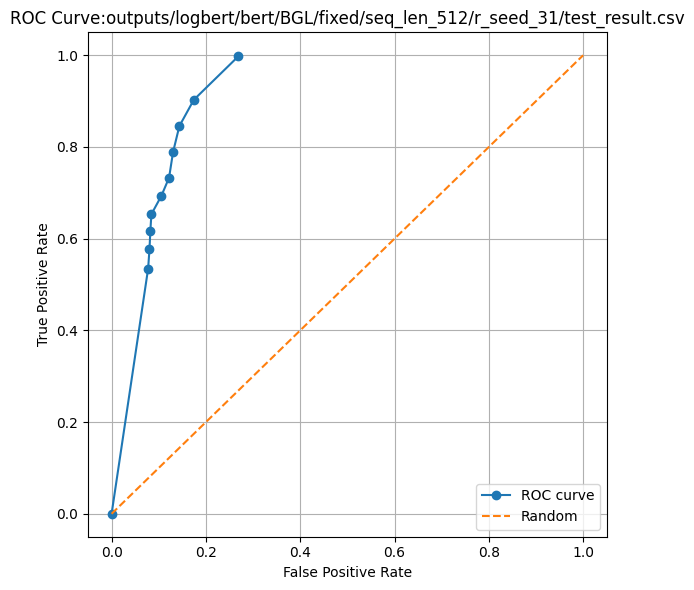

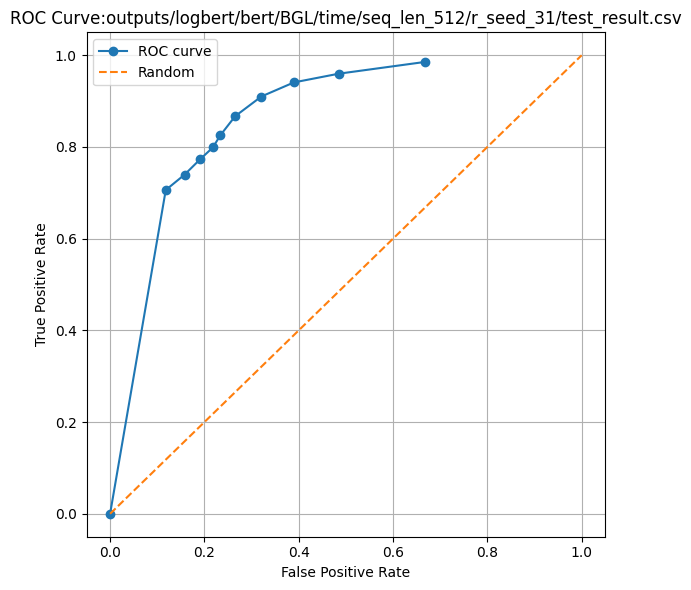

In [19]:
a.plot_roc(Path("outputs/logbert/bert/BGL/fixed/seq_len_512/r_seed_31/test_result.csv"))
a.plot_roc(Path("outputs/logbert/bert/BGL/time/seq_len_512/r_seed_31/test_result.csv"))


## Tbird

In [28]:
preprocess.prepare_tbird_model_data(
    logdata_filepath = INTERIM_DIR/"Tbird/Thunderbird_structured.csv",
    output_dir = PROCESSED_DIR/"Tbird/fixed",
    window_size = 300, 
    step_size = 150,
    mode = "fixed",
)

/home/siwamura/My_lad/src/preprocess.py:1286: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['deltaT'].fillna(0, inplace=True)


there are 133332 instances (sliding windows) in this dataset

vocab size 79166
Sequence Length Statistics Report
Generated: 2025-12-21 19:40:07
Mode: fixed
Window Size: 300
Step Size: 150

[Ratio: 0.8]
--------------------------------------------------
  train:
    Count:    63,332
    Avg Len:  300.00
    Min Len:  300
    Max Len:  300
    Std Dev:  0.00
  test_normal:
    Count:    15,834
    Avg Len:  300.00
    Min Len:  300
    Max Len:  300
    Std Dev:  0.00
  test_abnormal:
    Count:    54,166
    Avg Len:  300.00
    Min Len:  300
    Max Len:  300
    Std Dev:  0.00


Statistics saved to: ../data/processed/Tbird/fixed/seq_stats.txt


In [29]:
# サンプル数を5000まで削る
preprocess.extract_line(
    input_file=Path(PROCESSED_DIR/"Tbird/fixed/train_full"),
    output_file=Path(PROCESSED_DIR/"Tbird/fixed/train")
)

In [30]:
preprocess.extract_line(
    input_file=Path(PROCESSED_DIR/"Tbird/fixed/test_abnormal_full"),
    output_file=Path(PROCESSED_DIR/"Tbird/fixed/test_abnormal")
)

In [ ]:
# train
main.main_cli([
    "train",
    "bert/tbird",           # conf/bert_config_name.yaml
    #"default.device_id=0",        # ここに好きな key=value を並べる
    #"default.epochs=10",
])

In [33]:
# テスト
main.main_cli([
    "test",  # run_mode
    "outputs/logbert/bert/Tbird/fixed/seq_len_512/r_seed_31/weights/ValTotalbest.pth", # 重みファイルまでの相対パス
    "64",   # eval_batchsize
    "cuda:0",     # gpu
])

outputs/logbert/bert/Tbird/fixed/seq_len_512/r_seed_31
cuda:0 cuda:0
Building Vocab


100%|██████████| 79166/79166 [00:04<00:00, 16982.03it/s]


VOCAB SIZE: 1159


100%|██████████| 44892/44892 [03:57<00:00, 188.98it/s]


Saving test normal results
Saving test abnormal results
[seq_th, FP, TP, TN, FN, Precision, Recall, F1, TPR, FPR]
threshold=0.000['12613.0000', '44824.0000', '3195.0000', '68.0000', '78.0403', '99.8485', '87.6076', '99.8485', '79.7887']
threshold=0.100['10273.0000', '44351.0000', '5535.0000', '541.0000', '81.1932', '98.7949', '89.1334', '98.7949', '64.9861']
threshold=0.200['9062.0000', '43545.0000', '6746.0000', '1347.0000', '82.7742', '96.9995', '89.3240', '96.9995', '57.3254']
threshold=0.300['8233.0000', '42231.0000', '7575.0000', '2661.0000', '83.6854', '94.0724', '88.5754', '94.0724', '52.0812']
threshold=0.400['7538.0000', '37227.0000', '8270.0000', '7665.0000', '83.1610', '82.9257', '83.0432', '82.9257', '47.6847']
threshold=0.500['6882.0000', '28790.0000', '8926.0000', '16102.0000', '80.7076', '64.1317', '71.4711', '64.1317', '43.5349']
threshold=0.600['6245.0000', '22850.0000', '9563.0000', '22042.0000', '78.5358', '50.8999', '61.7676', '50.8999', '39.5053']
threshold=0.700['

/home/siwamura/My_lad/src/a.py:13: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  tpr = df["TPR"] / 100.0
/home/siwamura/My_lad/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


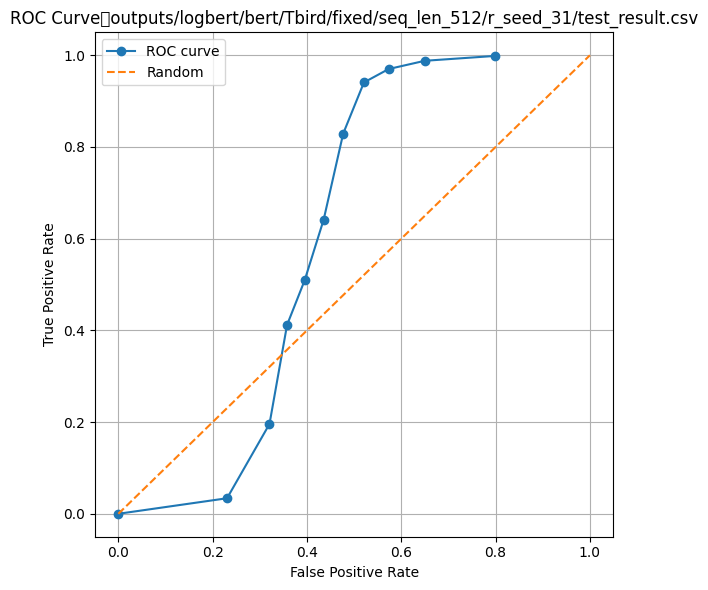

/home/siwamura/My_lad/src/a.py:13: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  tpr = df["TPR"] / 100.0
/home/siwamura/My_lad/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


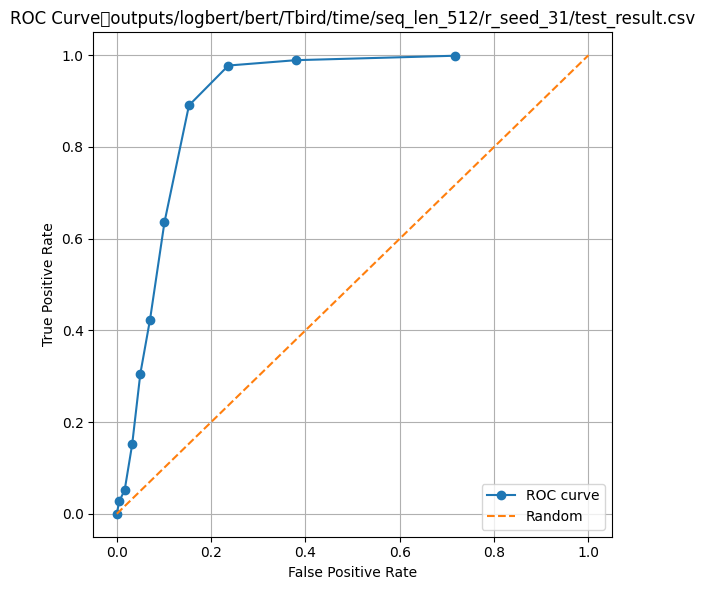

In [43]:
a.plot_roc(Path("outputs/logbert/bert/Tbird/fixed/seq_len_512/r_seed_31/test_result.csv"))
a.plot_roc(Path("outputs/logbert/bert/Tbird/time/seq_len_512/r_seed_31/test_result.csv"))


## Score

#### data

In [ ]:
# [EventID, score, score_missing]
preprocess.prepare_scores_model_data(
    output_dir = PROCESSED_DIR / "scores",
    #output_dir = Path("../data_tmp/scores"),
    window_size = 400,
    step_size = 200,
    mode = "fixed",
)

there are 9659 instances (sliding windows) in this dataset

there are 615 instances (sliding windows) in this dataset

there are 1357 instances (sliding windows) in this dataset

there are 581 instances (sliding windows) in this dataset

there are 1365 instances (sliding windows) in this dataset

there are 584 instances (sliding windows) in this dataset

Project info saved to ../data/processed/scores/fixed/train_projects.csv
Project info saved to ../data/processed/scores/fixed/test_normal_projects.csv
Project info saved to ../data/processed/scores/fixed/test_abnormal_projects.csv


In [9]:
embedding_converter.main(PROJECT_ROOT)

=== Loading embedding mapping ===
Loaded 425 embeddings (dim=384)

=== Converting train ===
Loaded 12381 instances
Saved embedded data to ../data/processed/scores/fixed_embedded/train.npz

=== Converting test_normal ===
Loaded 807 instances
Saved embedded data to ../data/processed/scores/fixed_embedded/test_normal.npz

=== Converting test_abnormal ===
Loaded 973 instances
Saved embedded data to ../data/processed/scores/fixed_embedded/test_abnormal.npz

=== Conversion complete ===


#### train

In [4]:
train_score_bert.run_from_notebook("score_bert")

Output directory: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847/
Device: cuda:0
Config: score_bert
Loading data from ../data/processed/scores/fixed_embedded/train.npz
Total samples: 12381
Training samples: 11143 (90%)
Validation samples: 1238 (10%)
Input dimension: 386, Sequence length: 200
Model parameters: 793,729


Epoch 1: 100%|██████████| 349/349 [00:03<00:00, 115.02it/s, loss=0.0103, score=31.7442, event=0.0103]


Epoch 1/70 - Train Loss: 0.0179 - Val Loss: 0.0171 - LR: 0.000100
  Saved best model (loss: 0.0171)


Epoch 2: 100%|██████████| 349/349 [00:02<00:00, 123.28it/s, loss=0.0131, score=5.2957, event=0.0131] 


Epoch 2/70 - Train Loss: 0.0150 - Val Loss: 0.0142 - LR: 0.000100
  Saved best model (loss: 0.0142)


...

Epoch 70: 100%|██████████| 349/349 [00:02<00:00, 125.06it/s, loss=0.0054, score=18.4469, event=0.0054]


Epoch 70/70 - Train Loss: 0.0068 - Val Loss: 0.0061 - LR: 0.000001
Loss history plot saved to: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847/loss_history.png

Computing error statistics for normalization...


Computing stats: 100%|██████████| 387/387 [00:01<00:00, 295.53it/s]


Error statistics saved to: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847/error_stats.json
  μ_score: 15.570488, σ_score: 99.001815
  μ_event: 0.014073, σ_event: 0.019182
  Score tokens: 2,386,696, Event tokens: 2,476,200

Training complete!
Best validation loss: 0.0061
Results saved to: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847


0.006069887369775619

#### test

In [10]:
results = test_score_bert_v1.run_from_notebook("../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847/", gamma=1.0)
print(f"ROC-AUC: {results['roc_auc']}")

Model loaded from: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847
Best epoch: 57, Best loss: 0.0061

Loading test data...
  Normal: ../data/processed/scores/fixed_embedded/test_normal.npz
  Abnormal: ../data/processed/scores/fixed_embedded/test_abnormal.npz
  Normal windows: 807
  Abnormal windows: 973

Computing anomaly scores (γ=1.0, percentile=95)...
  Formula: window_score = P95(raw_score_err) + γ * P95(event_context_err)


  Normal scores: mean=83.9189, std=225.2098
  Abnormal scores: mean=406.0961, std=2729.6267

Generating plots...
Timeline plot saved to: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847/eval_v1/timeline_v1.png
Score components plot saved to: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847/eval_v1/score_components_v1.png
ROC/PR curves saved to: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847/eval_v1/roc_pr_curves_v1.png
Metrics curves saved to: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847/eval_v1/metrics_curves_v1.png

EVALUATION RESULTS (V1 - Percentile-based)
Scoring: P95(score_err) + 1.0 * P95(event_err)
ROC-AUC: 0.5051
PR-AUC:  0.5451
Best F1: 0.7069 (threshold=0.0962)
Results saved to: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847/eval_v1
ROC-AUC: 0.5050973559973052


#### diagnorsis

In [ ]:
results = diagnosis_v1.run_from_notebook("../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847",gamma=1.0)

Running diagnosis (V1) for: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847
  Formula: window_score = P95(raw_score_err) + 10 * P95(event_context_err)

Loading test data...
  Normal windows: 807
  Abnormal windows: 973

Computing detailed statistics (raw errors)...



Generating diagnosis plots (V1)...
Raw histograms saved to: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847/diagnosis_v1/histograms_raw_v1.png
Combined histograms saved to: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847/diagnosis_v1/combined_histograms_v1.png
Missing ratio plot saved to: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847/diagnosis_v1/missing_ratio_v1.png
Raw error histograms saved to: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847/diagnosis_v1/error_raw_histograms_v1.png
Score-Event scatter plot saved to: ../outputs/score_bert/score_bert/hidden_128/layers_3/r_seed_42/20260105_172847/diagnosis_v1/score_event_scatter_v1.png

DIAGNOSIS RESULTS (V1 - Percentile-based)

Scoring Formula:
  window_score = P95(raw_score_err) + 10 × P95(event_context_err)

Separate AUC Evaluation (P95-based):
  Score Part AUC:  0.5053
  Event Part AUC:  0.5571

Aggregation

# 追加検証

### 下準備（ハッシュ値の用意）
- すべてを一括で行わないとデータが壊れる

In [5]:
projects = ["T1105","WEB1","WEB2","T1055","T1007"]

for project in projects:
    process_csv(
        input_csv_path=INTERIM_DIR/f'{project}/security2_structured.csv',
        output_csv_path=INTERIM_DIR/f'{project}/security2_structured_unmasked.csv',
        no_mask_config="no_mask.json",
        new_column_name='EventTemplateUnmasked',
        hash_method="md5",
    )

Loading no_mask config from: no_mask.json
Loading CSV from: ../data/interim/T1105/security2_structured.csv
Total rows: 177827
Columns: ['Level', 'EventID', 'EventRecordID', 'TimeCreated_SystemTime', 'Channel', 'Task', 'Provider_Name', 'Correlation_RelatedActivityID', 'Execution_ProcessID', 'Execution_ThreadID', 'Security_UserID', 'Keywords', 'Content', 'Correlation_ActivityID', 'Provider_Guid', 'Computer', 'Opcode', 'Version', 'Label', 'date', 'EventId', 'EventTemplate']

Processing EventID: 4688, Attributes: ['NewProcessName', 'ParentProcessName']
  Found 5962 rows with EventID=4688

Processing EventID: 5156, Attributes: ['Application', 'DestPort', 'Protocol', 'Direction']
  Found 77553 rows with EventID=5156

Processing EventID: 4673, Attributes: ['ObjectServer', 'Service', 'PrivilegeList', 'ProcessName']
  Found 3317 rows with EventID=4673

Processing EventID: 4702, Attributes: ['SubjectDomainName', 'TaskName']
  Found 4980 rows with EventID=4702

Processing EventID: 5447, Attribute

/home/ubuntu/My_lad/src/unmask_attributes.py:267: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv_path, index_col=0)


Total rows: 60000
Columns: ['Unnamed: 0', 'EventID', 'Level', 'Correlation_ActivityID', 'Computer', 'Content', 'Provider_Name', 'Opcode', 'Provider_Guid', 'Task', 'Keywords', 'Correlation_RelatedActivityID', 'Execution_ThreadID', 'Security_UserID', 'TimeCreated_SystemTime', 'Version', 'Execution_ProcessID', 'Channel', 'EventRecordID', 'Label', 'EventId', 'EventTemplate']

Processing EventID: 4688, Attributes: ['NewProcessName', 'ParentProcessName']
  Found 28 rows with EventID=4688

Processing EventID: 5156, Attributes: ['Application', 'DestPort', 'Protocol', 'Direction']
  Found 21 rows with EventID=5156

Processing EventID: 4673, Attributes: ['ObjectServer', 'Service', 'PrivilegeList', 'ProcessName']
  Found 9 rows with EventID=4673

Processing EventID: 4702, Attributes: ['SubjectDomainName', 'TaskName']
  Found 0 rows with EventID=4702

Processing EventID: 5447, Attributes: ['ProviderKey', 'ProviderName', 'Action']
  Found 0 rows with EventID=5447

Generating MD5 hash column: EventT

## train(T1105) ⇒ test(T1105, WEB1, WEB2, T1055)
- プロジェクト名：ex1

### モデル前データ作成

In [6]:
eventid = "EventTemplateUnmaskedHash_md5"
preprocess.prepare_model_train_data(
    logdata_filepath = INTERIM_DIR / "T1105(full)/security2_structured_unmasked.csv",
    output_dir = PROCESSED_DIR / "ex1",
    train_ratio=0.94,
    features = [f"{eventid}", "deltaT"],
    use_columns = ["timestamp", "Label", "EventID", f"{eventid}", "deltaT"],
    window_size = 430,
    step_size = 200,
    mode = "fixed", 
)

/home/ubuntu/My_lad/src/preprocess.py:865: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 5137 instances (sliding windows) in this dataset

training size 4822
Sequence Length Statistics Report
Generated: 2026-01-25 13:56:22
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: 0.94]
--------------------------------------------------
  train:
    Count:    4,822
    Avg Len:  4822.00
    Min Len:  4822
    Max Len:  4822
    Std Dev:  0.00


Statistics saved to: ../data/processed/ex1/seq_stats.txt


In [7]:
preprocess.prepare_model_test_data(
    logdata_filepath = INTERIM_DIR / "T1105(full)/security2_structured_unmasked.csv",
    output_dir = PROCESSED_DIR / "ex1/T1105",
    train_ratio=0.94,
    features = [f"{eventid}", "deltaT"],
    use_columns = ["timestamp", "Label", "EventID", f"{eventid}", "deltaT"],
    window_size = 430,
    step_size = 200,
    mode = "fixed", 
)

/home/ubuntu/My_lad/src/preprocess.py:945: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 5137 instances (sliding windows) in this dataset

test normal size 308
test abnormal size 7
Sequence Length Statistics Report
Generated: 2026-01-25 13:56:35
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: 0.94]
--------------------------------------------------
  test_normal:
    Count:    308
    Avg Len:  308.00
    Min Len:  308
    Max Len:  308
    Std Dev:  0.00
  test_abnormal:
    Count:    7
    Avg Len:  7.00
    Min Len:  7
    Max Len:  7
    Std Dev:  0.00


Statistics saved to: ../data/processed/ex1/T1105/seq_stats.txt


In [8]:
preprocess.prepare_model_test_data(
    logdata_filepath = INTERIM_DIR / "WEB1/security2_structured_unmasked.csv",
    output_dir = PROCESSED_DIR / "ex1/WEB1",
    train_ratio=0.7,
    features = [f"{eventid}", "deltaT"],
    use_columns = ["timestamp", "Label", "EventID", f"{eventid}", "deltaT"],
    window_size = 430,
    step_size = 200,
    mode = "fixed", 
)

preprocess.prepare_model_test_data(
    logdata_filepath = INTERIM_DIR / "WEB2/security2_structured_unmasked.csv",
    output_dir = PROCESSED_DIR / "ex1/WEB2",
    train_ratio=0.7,
    features = [f"{eventid}", "deltaT"],
    use_columns = ["timestamp", "Label", "EventID", f"{eventid}", "deltaT"],
    window_size = 430,
    step_size = 200,
    mode = "fixed", 
)

/home/ubuntu/My_lad/src/preprocess.py:945: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 969 instances (sliding windows) in this dataset

test normal size 218
test abnormal size 243
Sequence Length Statistics Report
Generated: 2026-01-25 13:56:39
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: 0.7]
--------------------------------------------------
  test_normal:
    Count:    218
    Avg Len:  218.00
    Min Len:  218
    Max Len:  218
    Std Dev:  0.00
  test_abnormal:
    Count:    243
    Avg Len:  243.00
    Min Len:  243
    Max Len:  243
    Std Dev:  0.00


Statistics saved to: ../data/processed/ex1/WEB1/seq_stats.txt


/home/ubuntu/My_lad/src/preprocess.py:945: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 1077 instances (sliding windows) in this dataset

test normal size 248
test abnormal size 251
Sequence Length Statistics Report
Generated: 2026-01-25 13:56:42
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: 0.7]
--------------------------------------------------
  test_normal:
    Count:    248
    Avg Len:  248.00
    Min Len:  248
    Max Len:  248
    Std Dev:  0.00
  test_abnormal:
    Count:    251
    Avg Len:  251.00
    Min Len:  251
    Max Len:  251
    Std Dev:  0.00


Statistics saved to: ../data/processed/ex1/WEB2/seq_stats.txt


In [9]:
preprocess.prepare_model_test_data(
    logdata_filepath = INTERIM_DIR / "T1055/security2_structured_unmasked.csv",
    output_dir = PROCESSED_DIR / "ex1/T1055",
    train_ratio=0.85, #すべてのデータをテストデータとして用いる
    features = [f"{eventid}", "deltaT"],
    use_columns = ["timestamp", "Label", "EventID", f"{eventid}", "deltaT"],
    window_size = 430,
    step_size = 200,
    mode = "fixed", 
)

/home/ubuntu/My_lad/src/preprocess.py:945: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 7241 instances (sliding windows) in this dataset

test normal size 1086
test abnormal size 6
Sequence Length Statistics Report
Generated: 2026-01-25 13:57:00
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: 0.85]
--------------------------------------------------
  test_normal:
    Count:    1,086
    Avg Len:  1086.00
    Min Len:  1086
    Max Len:  1086
    Std Dev:  0.00
  test_abnormal:
    Count:    6
    Avg Len:  6.00
    Min Len:  6
    Max Len:  6
    Std Dev:  0.00


Statistics saved to: ../data/processed/ex1/T1055/seq_stats.txt


In [10]:
preprocess.prepare_model_test_data(
    logdata_filepath = INTERIM_DIR / "T1007/security2_structured_unmasked.csv",
    output_dir = PROCESSED_DIR / "ex1/T1007",
    train_ratio=0.0, #すべてのデータをテストデータとして用いる
    features = [f"{eventid}", "deltaT"],
    use_columns = ["timestamp", "Label", "EventID", f"{eventid}", "deltaT"],
    window_size = 430,
    step_size = 200,
    mode = "fixed", 
)

/home/ubuntu/My_lad/src/preprocess.py:938: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(logdata_filepath)
/home/ubuntu/My_lad/src/preprocess.py:945: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 298 instances (sliding windows) in this dataset

test normal size 288
test abnormal size 10
Sequence Length Statistics Report
Generated: 2026-01-25 13:57:02
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: 0.0]
--------------------------------------------------
  test_normal:
    Count:    288
    Avg Len:  288.00
    Min Len:  288
    Max Len:  288
    Std Dev:  0.00
  test_abnormal:
    Count:    10
    Avg Len:  10.00
    Min Len:  10
    Max Len:  10
    Std Dev:  0.00


Statistics saved to: ../data/processed/ex1/T1007/seq_stats.txt


### Train

In [11]:
# train
main.main_cli([
    "train",
    "bert/ex1",           # conf/bert_config_name.yaml
])

setup
Found 11 vocab source files:
  - ../data/processed/ex1/train
  - ../data/processed/ex1/T1007/test_abnormal
  - ../data/processed/ex1/T1007/test_normal
  - ../data/processed/ex1/T1055/test_abnormal
  - ../data/processed/ex1/T1055/test_normal
  - ../data/processed/ex1/T1105/test_abnormal
  - ../data/processed/ex1/T1105/test_normal
  - ../data/processed/ex1/WEB1/test_abnormal
  - ../data/processed/ex1/WEB1/test_normal
  - ../data/processed/ex1/WEB2/test_abnormal
  - ../data/processed/ex1/WEB2/test_normal
Total lines processed: 7487
Building Vocab


100%|██████████| 7487/7487 [00:00<00:00, 18402.30it/s]


VOCAB SIZE: 2088
DEBUG suggest_dataloader: cfg.dataset.vocab.vocab_size = None (type: <class 'str'>)
Updating vocab_size from None to 2088
After update: cfg.dataset.vocab.vocab_size = 2088
before filtering short session
train size  4340
valid size  482


100%|██████████| 4822/4822 [00:01<00:00, 2698.99it/s]


Num of train seqs 4340
Num of valid seqs 482
DEBUG main.py: cfg.dataset.vocab.vocab_size = 2088 (type: <class 'int'>)


...

epoch 68 || TRAIN_Loss:2.5483 ||VAL_Loss:2.5397
Best epoch = 50


135it [00:03, 36.44it/s]
15it [00:00, 115.19it/s]


epoch 69 || TRAIN_Loss:2.5484 ||VAL_Loss:2.5391
Best epoch = 50


135it [00:03, 36.71it/s]
15it [00:00, 118.50it/s]


epoch 70 || TRAIN_Loss:2.5450 ||VAL_Loss:2.5368
Early stopping at epoch 70 (best = 50)


### Test

In [16]:
# テスト
main.main_cli([
    "test",  # run_mode
    "../outputs/logbert/bert_no_time/ex1/seq_len_512/r_seed_31/weights/ValTotalbest.pth", # 重みファイルまでの相対パス
    "32",   # eval_batchsize
    "cuda:0",     # gpu
    "eval.dataset_dir=../data/processed/ex1/T1055"
])

../outputs/logbert/bert_no_time/ex1/seq_len_512/r_seed_31
cuda:0 cuda:0
Found 11 vocab source files:
  - ../data/processed/ex1/train
  - ../data/processed/ex1/T1007/test_abnormal
  - ../data/processed/ex1/T1007/test_normal
  - ../data/processed/ex1/T1055/test_abnormal
  - ../data/processed/ex1/T1055/test_normal
  - ../data/processed/ex1/T1105/test_abnormal
  - ../data/processed/ex1/T1105/test_normal
  - ../data/processed/ex1/WEB1/test_abnormal
  - ../data/processed/ex1/WEB1/test_normal
  - ../data/processed/ex1/WEB2/test_abnormal
  - ../data/processed/ex1/WEB2/test_normal
Total lines processed: 7487
Building Vocab


100%|██████████| 7487/7487 [00:00<00:00, 19977.22it/s]


VOCAB SIZE: 2088
Updated vocab_size to 2088


100%|██████████| 6/6 [00:00<00:00, 18.61it/s]

Saving test normal results
Saving test abnormal results
[seq_th, FP, TP, TN, FN, Precision, Recall, F1, TPR, FPR]
threshold=0.000['1054.0000', '6.0000', '2.0000', '0.0000', '0.5660', '100.0000', '1.1257', '100.0000', '99.8106']
threshold=0.100['1054.0000', '6.0000', '2.0000', '0.0000', '0.5660', '100.0000', '1.1257', '100.0000', '99.8106']
threshold=0.200['1054.0000', '6.0000', '2.0000', '0.0000', '0.5660', '100.0000', '1.1257', '100.0000', '99.8106']
threshold=0.300['1054.0000', '6.0000', '2.0000', '0.0000', '0.5660', '100.0000', '1.1257', '100.0000', '99.8106']
threshold=0.400['1051.0000', '6.0000', '5.0000', '0.0000', '0.5676', '100.0000', '1.1289', '100.0000', '99.5265']
threshold=0.500['895.0000', '6.0000', '161.0000', '0.0000', '0.6659', '100.0000', '1.3230', '100.0000', '84.7538']
threshold=0.600['325.0000', '5.0000', '731.0000', '1.0000', '1.5152', '83.3333', '2.9762', '83.3333', '30.7765']
threshold=0.700['73.0000', '2.0000', '983.0000', '4.0000', '2.6667', '33.3333', '4.9383'

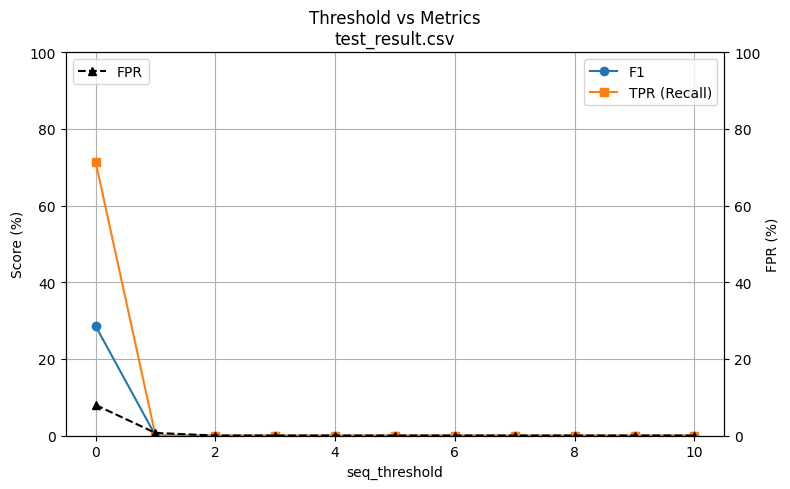

In [ ]:
a.plot_threshold_metrics(Path("../archive/21/T1105/test_result.csv"))

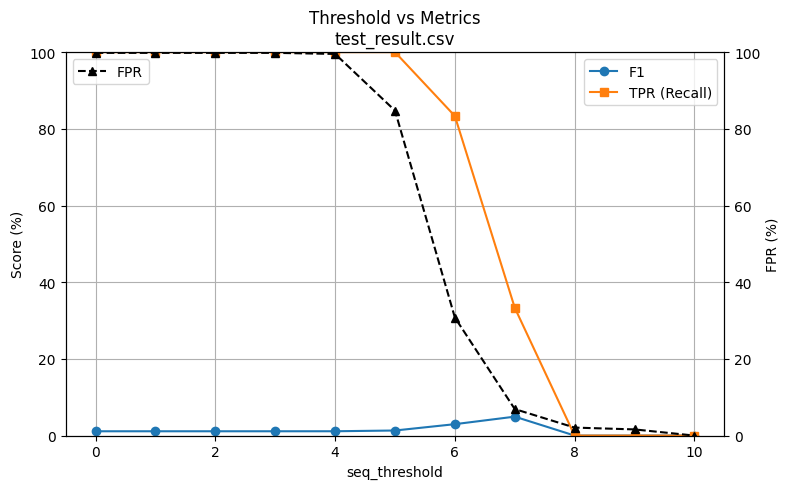

In [17]:
a.plot_threshold_metrics(Path("../outputs/logbert/bert_no_time/ex1/seq_len_512/r_seed_31/test_result.csv"))

### 可視化

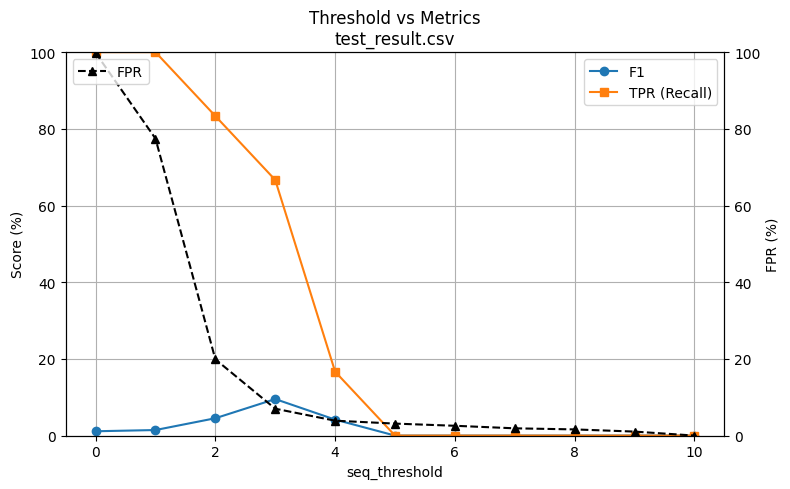

In [ ]:
a.plot_threshold_metrics(Path("../archive/17/T1055/test_result.csv"))

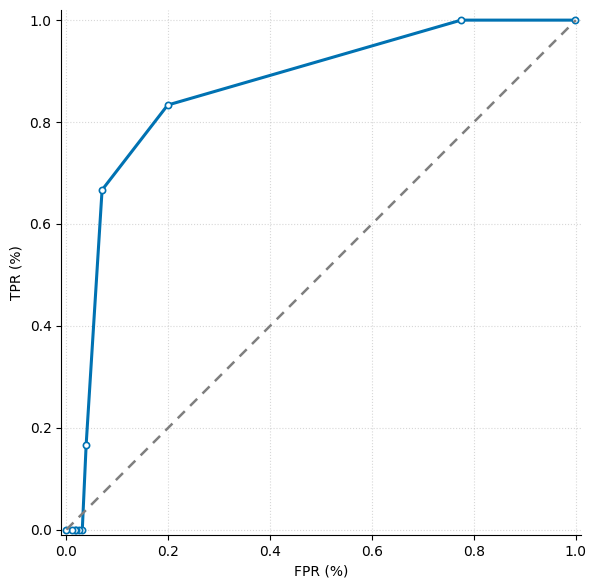

In [ ]:
a.plot_roc(Path("../archive/17/T1055/test_result.csv"))

In [ ]:
a.plot_pr(Path("../archive/17/T1055/test_result.csv"))

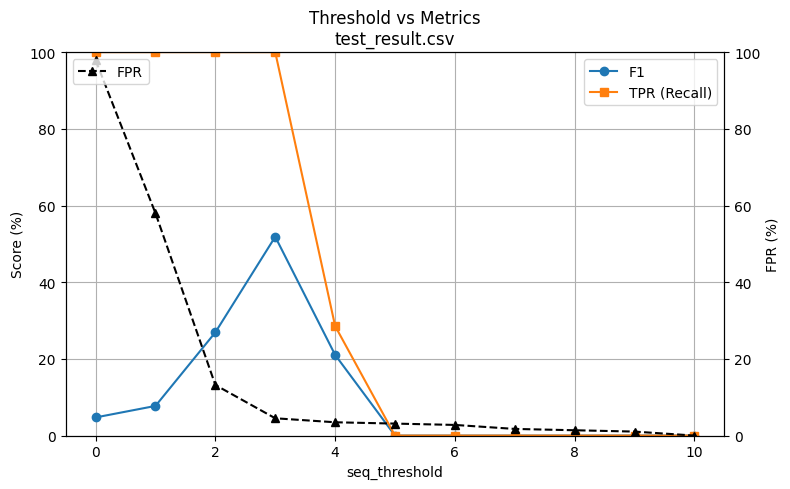

In [ ]:
a.plot_threshold_metrics(Path("../archive/17/T1105/test_result.csv"))

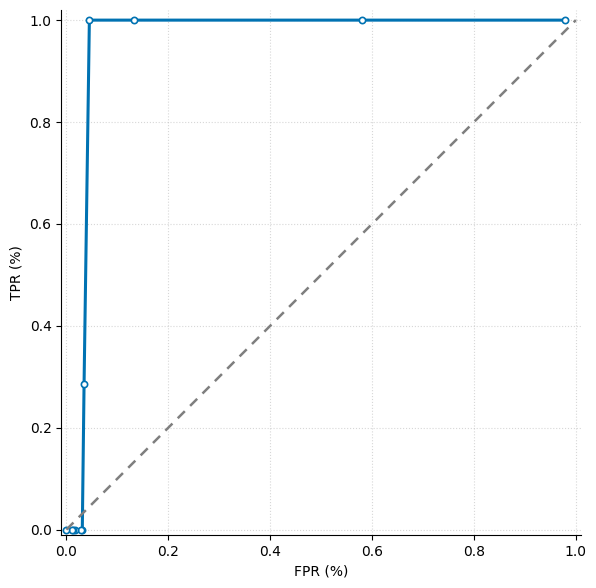

In [ ]:
a.plot_roc(Path("../archive/17/T1105/test_result.csv"))

In [ ]:
a.plot_pr(Path("../archive/17/T1105/test_result.csv"))

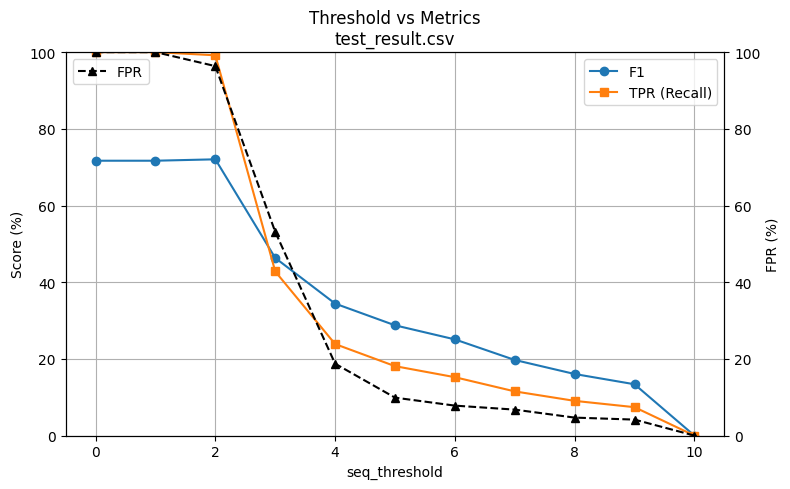

In [ ]:
a.plot_threshold_metrics(Path("../archive/17/WEB1/test_result.csv"))

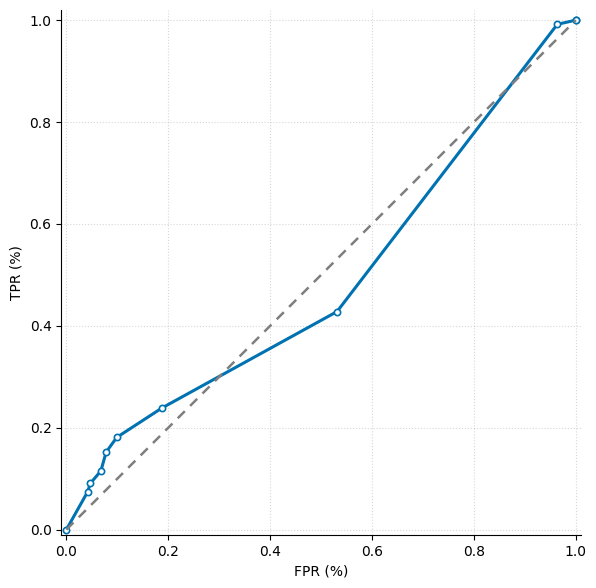

In [ ]:
a.plot_roc(Path("../archive/17/WEB1/test_result.csv"))

In [ ]:
a.plot_pr(Path("../archive/17/WEB1/test_result.csv"))

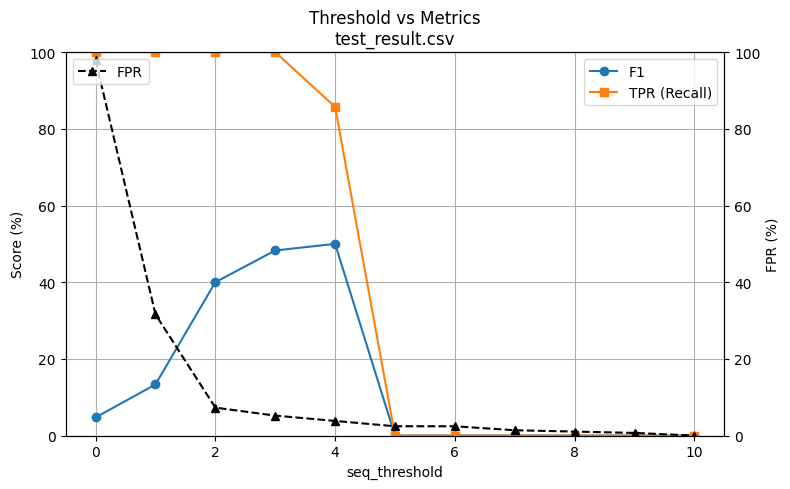

In [ ]:
a.plot_threshold_metrics(Path("../archive/11/T1105/test_result.csv"))

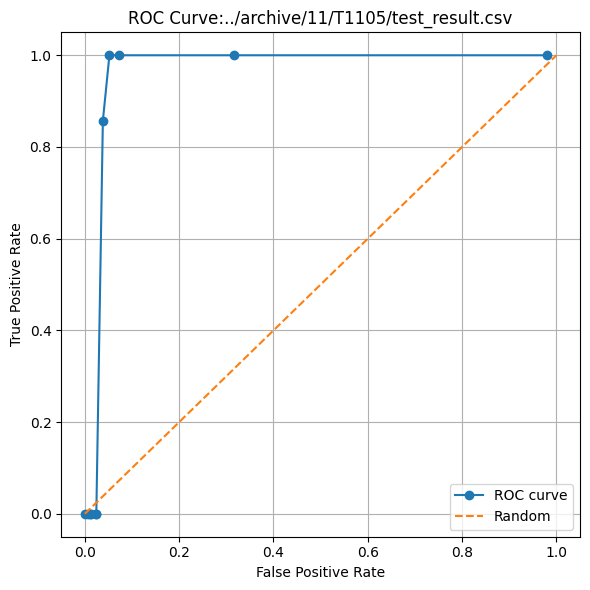

In [ ]:
a.plot_roc(Path("../archive/11/T1105/test_result.csv"))

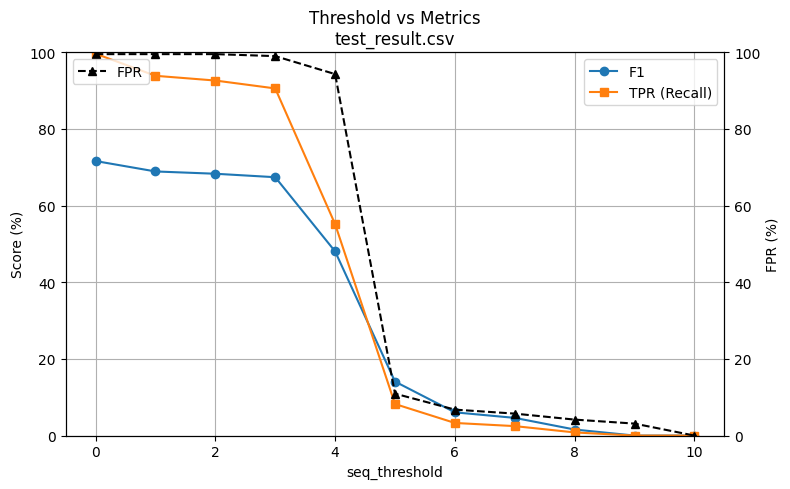

In [ ]:
a.plot_threshold_metrics(Path("../archive/11/WEB1/test_result.csv"))

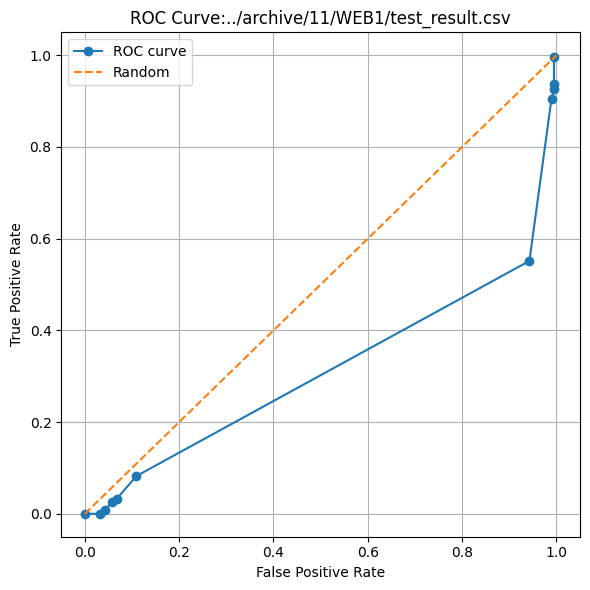

In [ ]:
a.plot_roc(Path("../archive/11/WEB1/test_result.csv"))

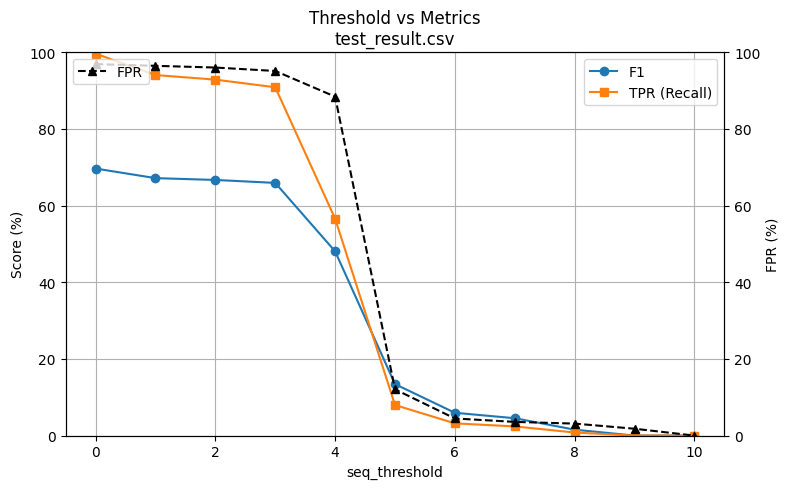

In [ ]:
a.plot_threshold_metrics(Path("../archive/11/WEB2/test_result.csv"))

## train(WEB1) ⇒ test(WEB1)
- プロジェクト名：ex2
- 次実験の前段

### モデル前データ作成

In [18]:
preprocess.prepare_model_train_data(
    logdata_filepath = INTERIM_DIR / "WEB1/security2_structured_unmasked.csv",
    output_dir = PROCESSED_DIR / "ex2",
    train_ratio=0.7,
    features = ["EventTemplateUnmaskedHash_md5", "deltaT"],
    use_columns = ["timestamp", "Label", "EventID", "EventTemplateUnmaskedHash_md5", "deltaT"],
    window_size = 430,
    step_size = 200,
    mode = "fixed", 
)

/home/ubuntu/My_lad/src/preprocess.py:865: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 969 instances (sliding windows) in this dataset

training size 508
Sequence Length Statistics Report
Generated: 2026-01-25 19:38:38
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: 0.7]
--------------------------------------------------
  train:
    Count:    508
    Avg Len:  508.00
    Min Len:  508
    Max Len:  508
    Std Dev:  0.00


Statistics saved to: ../data/processed/ex2/seq_stats.txt


### 検証

In [ ]:
# train
main.main_cli([
    "train",
    "bert/ex2",           # conf/bert_config_name.yaml
])

In [38]:
# テスト
main.main_cli([
    "test",  # run_mode
    "../outputs/logbert/bert_no_time/ex3/seq_len_512/r_seed_31/weights/ValTotalbest.pth", # 重みファイルまでの相対パス
    "32",   # eval_batchsize
    "cuda:0",     # gpu
    "eval.dataset_dir=../data/processed/ex3/T1055",
])

../outputs/logbert/bert_no_time/ex3/seq_len_512/r_seed_31
cuda:0 cuda:0
Found 9 vocab source files:
  - ../data/processed/ex3/train
  - ../data/processed/ex3/T1055/test_abnormal
  - ../data/processed/ex3/T1055/test_normal
  - ../data/processed/ex3/T1105/test_abnormal
  - ../data/processed/ex3/T1105/test_normal
  - ../data/processed/ex3/WEB1/test_abnormal
  - ../data/processed/ex3/WEB1/test_normal
  - ../data/processed/ex3/WEB2/test_abnormal
  - ../data/processed/ex3/WEB2/test_normal
Total lines processed: 8275
Building Vocab


100%|██████████| 8275/8275 [00:00<00:00, 20041.00it/s]


VOCAB SIZE: 2419
Updated vocab_size to 2419


100%|██████████| 6/6 [00:00<00:00, 10.82it/s]

Saving test normal results
Saving test abnormal results
[seq_th, FP, TP, TN, FN, Precision, Recall, F1, TPR, FPR]
threshold=0.000['1054.0000', '6.0000', '2.0000', '0.0000', '0.5660', '100.0000', '1.1257', '100.0000', '99.8106']
threshold=0.100['1054.0000', '6.0000', '2.0000', '0.0000', '0.5660', '100.0000', '1.1257', '100.0000', '99.8106']
threshold=0.200['1054.0000', '6.0000', '2.0000', '0.0000', '0.5660', '100.0000', '1.1257', '100.0000', '99.8106']
threshold=0.300['1042.0000', '6.0000', '14.0000', '0.0000', '0.5725', '100.0000', '1.1385', '100.0000', '98.6742']
threshold=0.400['756.0000', '5.0000', '300.0000', '1.0000', '0.6570', '83.3333', '1.3038', '83.3333', '71.5909']
threshold=0.500['255.0000', '4.0000', '801.0000', '2.0000', '1.5444', '66.6667', '3.0189', '66.6667', '24.1477']
threshold=0.600['68.0000', '0.0000', '988.0000', '6.0000', '0.0000', '0.0000', '0.0000', '0.0000', '6.4394']
threshold=0.700['26.0000', '0.0000', '1030.0000', '6.0000', '0.0000', '0.0000', '0.0000', '0.0

### 可視化

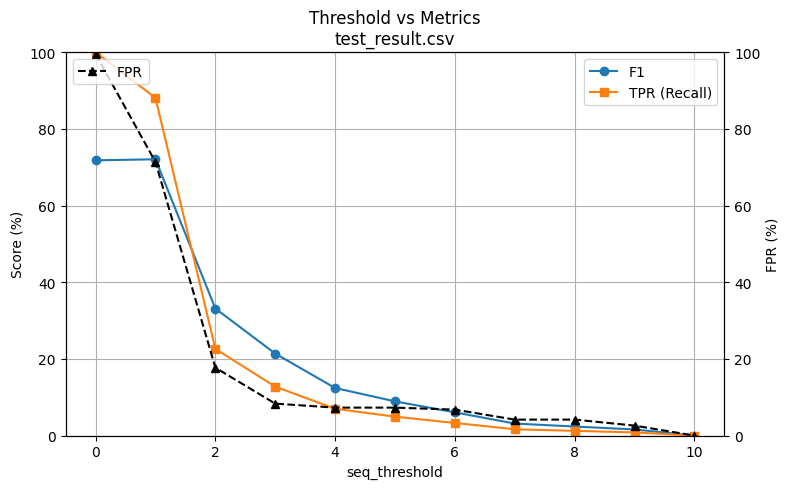

In [39]:
a.plot_threshold_metrics(Path("../archive/20/test_result.csv"))

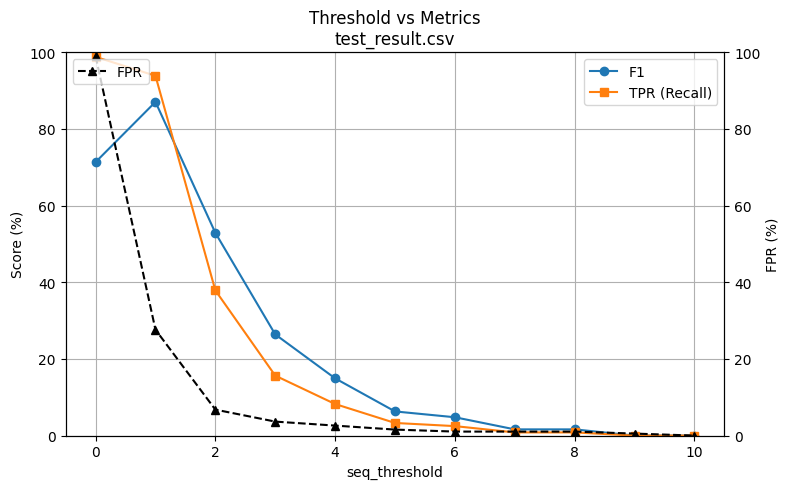

In [ ]:
a.plot_threshold_metrics(Path("../archive/12/test_result.csv"))

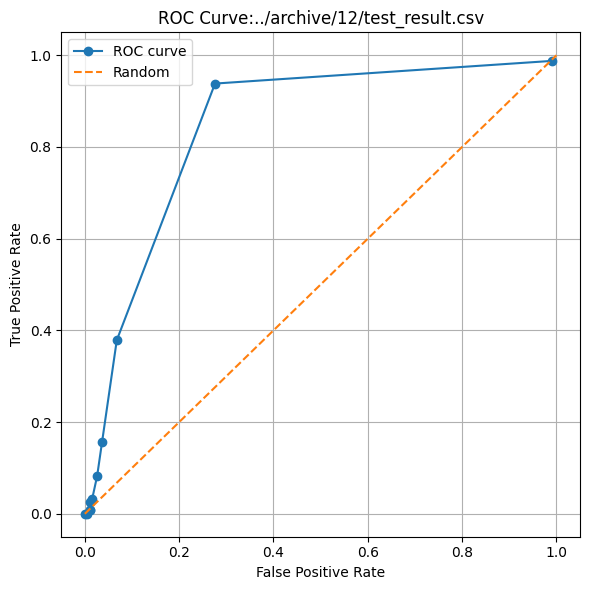

In [ ]:
a.plot_roc(Path("../archive/12/test_result.csv"))

## train(T1105 ＋ WEB1 + WEB2) ⇒ test(WEB1, WEB2)
- プロジェクト名：ex3

### モデル前データ作成

In [19]:
preprocess.prepare_model_train_data(
    logdata_filepath = INTERIM_DIR / "WEB2/security2_structured_unmasked.csv",
    output_dir = PROCESSED_DIR / "tmp",
    train_ratio=0.7,
    features = ["EventTemplateUnmaskedHash_md5", "deltaT"],
    use_columns = ["timestamp", "Label", "EventID", "EventTemplateUnmaskedHash_md5", "deltaT"],
    window_size = 430,
    step_size = 200,
    mode = "fixed", 
)

/home/ubuntu/My_lad/src/preprocess.py:865: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 1077 instances (sliding windows) in this dataset

training size 578
Sequence Length Statistics Report
Generated: 2026-01-25 19:38:54
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: 0.7]
--------------------------------------------------
  train:
    Count:    578
    Avg Len:  578.00
    Min Len:  578
    Max Len:  578
    Std Dev:  0.00


Statistics saved to: ../data/processed/tmp/seq_stats.txt


In [22]:
preprocess.merge_processed_files(
    PROCESSED_DIR/"ex1"/"train", # T1105のtrain
    PROCESSED_DIR/"ex2"/"train", # WEB1のtrain
    PROCESSED_DIR/"tmp/train", # WEB2のtrain
    output_dir=PROCESSED_DIR/"ex3",
    output_filename="train",  # 結合後のファイル名
    mode="fixed",               # seq_stats.txt用のモード
    window_size=430,            # seq_stats.txt用のウィンドウサイズ
    step_size=200,              # seq_stats.txt用のステップサイズ
)

Merged 4822 lines from train
Merged 508 lines from train
Merged 578 lines from train
Total: 5908 lines
Output saved to: ../data/processed/ex3/train
Sequence Length Statistics Report
Generated: 2026-01-25 19:39:36
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: merged]
--------------------------------------------------
  train:
    Count:    5,908
    Avg Len:  430.00
    Min Len:  430
    Max Len:  430
    Std Dev:  0.00


Statistics saved to: ../data/processed/ex3/seq_stats.txt


### 検証

In [ ]:
# train
main.main_cli([
    "train",
    "bert/ex3",           # conf/bert_config_name.yaml
])

In [30]:
# テスト
main.main_cli([
    "test",  # run_mode
    "../outputs/logbert/bert_no_time/ex3/seq_len_512/r_seed_31/weights/ValTotalbest.pth", # 重みファイルまでの相対パス
    "32",   # eval_batchsize
    "cuda:0",     # gpu
    "eval.dataset_dir=../data/processed/ex3/WEB1",
])

../outputs/logbert/bert_no_time/ex3/seq_len_512/r_seed_31
cuda:0 cuda:0
Found 9 vocab source files:
  - ../data/processed/ex3/train
  - ../data/processed/ex3/T1055/test_abnormal
  - ../data/processed/ex3/T1055/test_normal
  - ../data/processed/ex3/T1105/test_abnormal
  - ../data/processed/ex3/T1105/test_normal
  - ../data/processed/ex3/WEB1/test_abnormal
  - ../data/processed/ex3/WEB1/test_normal
  - ../data/processed/ex3/WEB2/test_abnormal
  - ../data/processed/ex3/WEB2/test_normal
Total lines processed: 8275
Building Vocab


100%|██████████| 8275/8275 [00:00<00:00, 19493.94it/s]


VOCAB SIZE: 2419
Updated vocab_size to 2419


100%|██████████| 243/243 [00:01<00:00, 183.48it/s]


Saving test normal results
Saving test abnormal results
[seq_th, FP, TP, TN, FN, Precision, Recall, F1, TPR, FPR]
threshold=0.000['192.0000', '243.0000', '0.0000', '0.0000', '55.8621', '100.0000', '71.6814', '100.0000', '100.0000']
threshold=0.100['192.0000', '243.0000', '0.0000', '0.0000', '55.8621', '100.0000', '71.6814', '100.0000', '100.0000']
threshold=0.200['190.0000', '243.0000', '2.0000', '0.0000', '56.1201', '100.0000', '71.8935', '100.0000', '98.9583']
threshold=0.300['132.0000', '190.0000', '60.0000', '53.0000', '59.0062', '78.1893', '67.2566', '78.1893', '68.7500']
threshold=0.400['53.0000', '70.0000', '139.0000', '173.0000', '56.9106', '28.8066', '38.2514', '28.8066', '27.6042']
threshold=0.500['20.0000', '49.0000', '172.0000', '194.0000', '71.0145', '20.1646', '31.4103', '20.1646', '10.4167']
threshold=0.600['15.0000', '39.0000', '177.0000', '204.0000', '72.2222', '16.0494', '26.2626', '16.0494', '7.8125']
threshold=0.700['13.0000', '29.0000', '179.0000', '214.0000', '69.

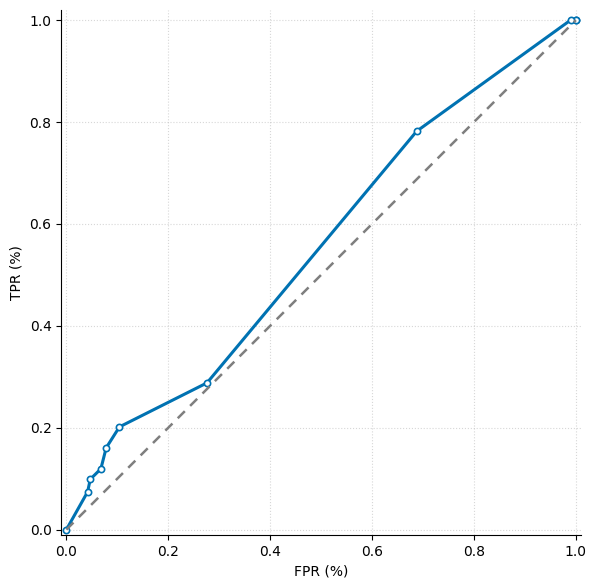

In [32]:
a.plot_roc(Path("../outputs/logbert/bert_no_time/ex3/seq_len_512/r_seed_31/test_result.csv"))

### 可視化

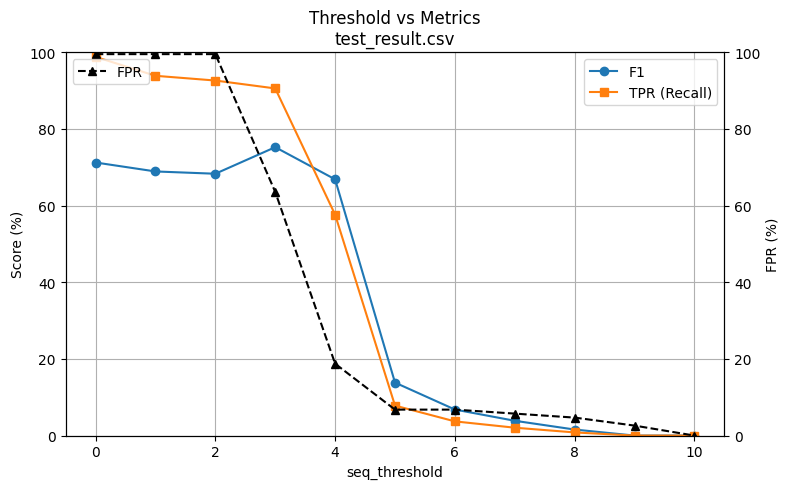

In [16]:
a.plot_threshold_metrics(Path("../archive/13/test_result.csv"))

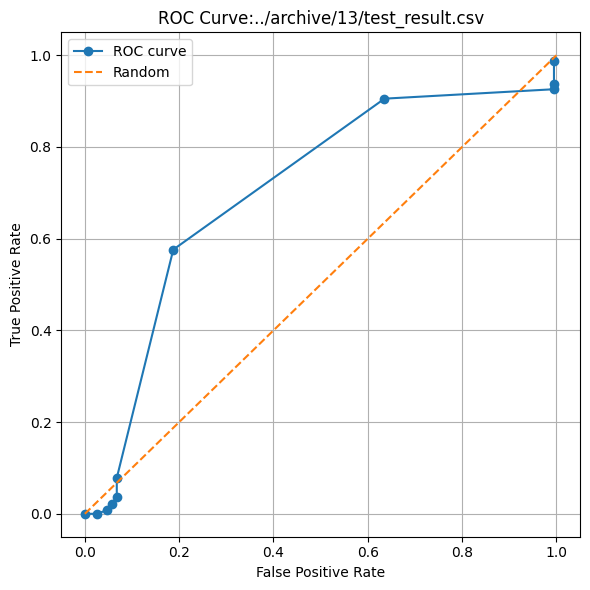

In [18]:
a.plot_roc(Path("../archive/13/test_result.csv"))

## train(T1105)：後端500行に絞る ⇒ test(WEB1)
- プロジェクト名：ex4
- データ量による精度変化の観察

### モデル前データ作成

In [7]:
preprocess.extract_lines_from_processed(
    input_path=Path("../data/processed/ex1/train"),
    output_dir=Path("../data/processed/ex4"),
    from_tail = 500,
)

Input file: ../data/processed/ex1/train
Total lines in input: 4822
Extracting 500 lines from tail
Extracted lines: 4323 to 4822 (500 lines)
Output saved to: ../data/processed/ex4/train
Sequence Length Statistics Report
Generated: 2026-01-16 00:49:00
Mode: fixed
Window Size: 0
Step Size: 0

[Ratio: extracted]
--------------------------------------------------
  train:
    Count:    500
    Avg Len:  430.00
    Min Len:  430
    Max Len:  430
    Std Dev:  0.00


Statistics saved to: ../data/processed/ex4/seq_stats.txt


### Train

In [ ]:
# train
main.main_cli([
    "train",
    "bert/ex4",           # conf/bert_config_name.yaml
])

### Test

In [11]:
# テスト
main.main_cli([
    "test",  # run_mode
    "../outputs/logbert/bert_no_time/ex4/seq_len_512/r_seed_31/weights/ValTotalbest.pth", # 重みファイルまでの相対パス
    "32",   # eval_batchsize
    "cuda:0",     # gpu
    "eval.dataset_dir=../data/processed/ex4/T1105",
])

../outputs/logbert/bert_no_time/ex4/seq_len_512/r_seed_31
cuda:0 cuda:0
Found 3 vocab source files:
  - ../data/processed/ex4/train
  - ../data/processed/ex4/T1105/test_abnormal
  - ../data/processed/ex4/T1105/test_normal
Total lines processed: 815
Building Vocab


100%|██████████| 815/815 [00:00<00:00, 17830.41it/s]


VOCAB SIZE: 1640
Updated vocab_size to 1640


100%|██████████| 7/7 [00:00<00:00, 14.89it/s]

Saving test normal results
Saving test abnormal results
[seq_th, FP, TP, TN, FN, Precision, Recall, F1, TPR, FPR]
threshold=0.000['282.0000', '7.0000', '6.0000', '0.0000', '2.4221', '100.0000', '4.7297', '100.0000', '97.9167']
threshold=0.100['123.0000', '7.0000', '165.0000', '0.0000', '5.3846', '100.0000', '10.2190', '100.0000', '42.7083']
threshold=0.200['22.0000', '7.0000', '266.0000', '0.0000', '24.1379', '100.0000', '38.8889', '100.0000', '7.6389']
threshold=0.300['13.0000', '7.0000', '275.0000', '0.0000', '35.0000', '100.0000', '51.8519', '100.0000', '4.5139']
threshold=0.400['11.0000', '7.0000', '277.0000', '0.0000', '38.8889', '100.0000', '56.0000', '100.0000', '3.8194']
threshold=0.500['6.0000', '1.0000', '282.0000', '6.0000', '14.2857', '14.2857', '14.2857', '14.2857', '2.0833']
threshold=0.600['3.0000', '0.0000', '285.0000', '7.0000', '0.0000', '0.0000', '0.0000', '0.0000', '1.0417']
threshold=0.700['1.0000', '0.0000', '287.0000', '7.0000', '0.0000', '0.0000', '0.0000', '0.0

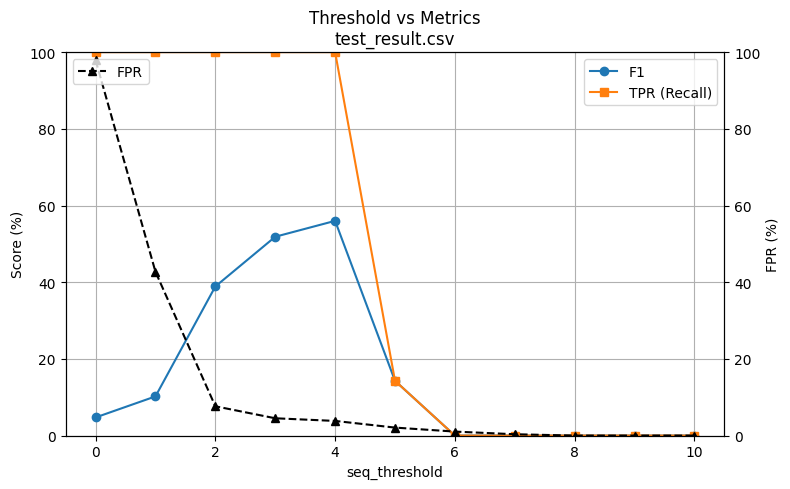

In [23]:
a.plot_threshold_metrics(Path("../archive/14/test_result.csv"))

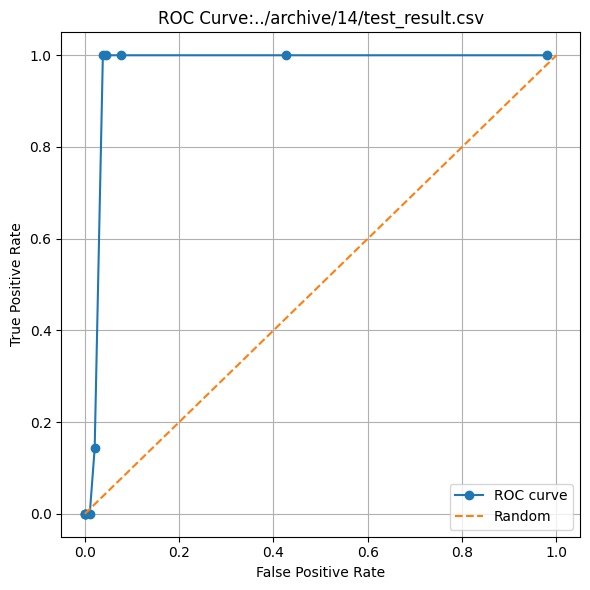

In [ ]:
a.plot_threshold(Path("../archive/14/test_result.csv"))

## train(T1055) ⇒ test(T1055, T1105)
- プロジェクト名：ex5
- unmask いろいろ試す

### モデル前データ作成

In [6]:
preprocess.prepare_model_train_data(
    logdata_filepath = INTERIM_DIR / "T1055/security2_structured_unmasked.csv",
    output_dir = PROCESSED_DIR / "ex5",
    train_ratio=0.85,
    features = [f"EventTemplateUnmaskedHash_{hash_method}", "deltaT"],
    use_columns = ["timestamp", "Label", "EventID", f"EventTemplateUnmaskedHash_{hash_method}", "deltaT"],
    window_size = 430,
    step_size = 200,
    mode = "fixed", 
)

/home/ubuntu/My_lad/src/preprocess.py:865: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 7241 instances (sliding windows) in this dataset

training size 6149
Sequence Length Statistics Report
Generated: 2026-01-16 22:00:24
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: 0.85]
--------------------------------------------------
  train:
    Count:    6,149
    Avg Len:  6149.00
    Min Len:  6149
    Max Len:  6149
    Std Dev:  0.00


Statistics saved to: ../data/processed/ex5/seq_stats.txt


In [7]:
preprocess.prepare_model_test_data(
    logdata_filepath = INTERIM_DIR / "T1055/security2_structured_unmasked.csv",
    output_dir = PROCESSED_DIR / "ex5/T1055",
    train_ratio=0.85,
    features = [f"EventTemplateUnmaskedHash_{hash_method}", "deltaT"],
    use_columns = ["timestamp", "Label", "EventID", f"EventTemplateUnmaskedHash_{hash_method}", "deltaT"],
    window_size = 430,
    step_size = 200,
    mode = "fixed", 
)

/home/ubuntu/My_lad/src/preprocess.py:945: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 7241 instances (sliding windows) in this dataset

test normal size 1086
test abnormal size 6
Sequence Length Statistics Report
Generated: 2026-01-16 22:00:44
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: 0.85]
--------------------------------------------------
  test_normal:
    Count:    1,086
    Avg Len:  1086.00
    Min Len:  1086
    Max Len:  1086
    Std Dev:  0.00
  test_abnormal:
    Count:    6
    Avg Len:  6.00
    Min Len:  6
    Max Len:  6
    Std Dev:  0.00


Statistics saved to: ../data/processed/ex5/T1055/seq_stats.txt


In [7]:
preprocess.extract_lines_from_processed(
    input_path=Path("../data/processed/T1055_full_train/train"),
    output_dir=Path("../data/processed/ex5"),
    from_tail = 1000,
)

Input file: ../data/processed/T1055_full_train/train
Total lines in input: 6149
Extracting 1000 lines from tail
Extracted lines: 5150 to 6149 (1000 lines)
Output saved to: ../data/processed/ex5/train
Sequence Length Statistics Report
Generated: 2026-01-16 02:04:30
Mode: fixed
Window Size: 0
Step Size: 0

[Ratio: extracted]
--------------------------------------------------
  train:
    Count:    1,000
    Avg Len:  430.00
    Min Len:  430
    Max Len:  430
    Std Dev:  0.00


Statistics saved to: ../data/processed/ex5/seq_stats.txt


### 検証

In [ ]:
# train
main.main_cli([
    "train",
    "bert/ex5",           # conf/bert_config_name.yaml
])

In [12]:
# テスト
main.main_cli([
    "test",  # run_mode
    "../outputs/logbert/bert_no_time/ex5/seq_len_512/r_seed_31/weights/ValTotalbest.pth", # 重みファイルまでの相対パス
    "32",   # eval_batchsize
    "cuda:0",     # gpu
    "eval.dataset_dir=../data/processed/ex5/T1105",
])

../outputs/logbert/bert_no_time/ex5/seq_len_512/r_seed_31
cuda:0 cuda:0
Found 5 vocab source files:
  - ../data/processed/ex5/train
  - ../data/processed/ex5/T1055/test_abnormal
  - ../data/processed/ex5/T1055/test_normal
  - ../data/processed/ex5/T1105/test_abnormal
  - ../data/processed/ex5/T1105/test_normal
Total lines processed: 7556
Building Vocab


100%|██████████| 7556/7556 [00:00<00:00, 16028.74it/s]


VOCAB SIZE: 2394
Updated vocab_size to 2394


100%|██████████| 7/7 [00:00<00:00, 11.88it/s]


Saving test normal results
Saving test abnormal results
[seq_th, FP, TP, TN, FN, Precision, Recall, F1, TPR, FPR]
threshold=0.000['288.0000', '7.0000', '0.0000', '0.0000', '2.3729', '100.0000', '4.6358', '100.0000', '100.0000']
threshold=0.100['288.0000', '7.0000', '0.0000', '0.0000', '2.3729', '100.0000', '4.6358', '100.0000', '100.0000']
threshold=0.200['288.0000', '7.0000', '0.0000', '0.0000', '2.3729', '100.0000', '4.6358', '100.0000', '100.0000']
threshold=0.300['288.0000', '7.0000', '0.0000', '0.0000', '2.3729', '100.0000', '4.6358', '100.0000', '100.0000']
threshold=0.400['288.0000', '7.0000', '0.0000', '0.0000', '2.3729', '100.0000', '4.6358', '100.0000', '100.0000']
threshold=0.500['261.0000', '7.0000', '27.0000', '0.0000', '2.6119', '100.0000', '5.0909', '100.0000', '90.6250']
threshold=0.600['170.0000', '6.0000', '118.0000', '1.0000', '3.4091', '85.7143', '6.5574', '85.7143', '59.0278']
threshold=0.700['57.0000', '0.0000', '231.0000', '7.0000', '0.0000', '0.0000', '0.0000', 

### 可視化

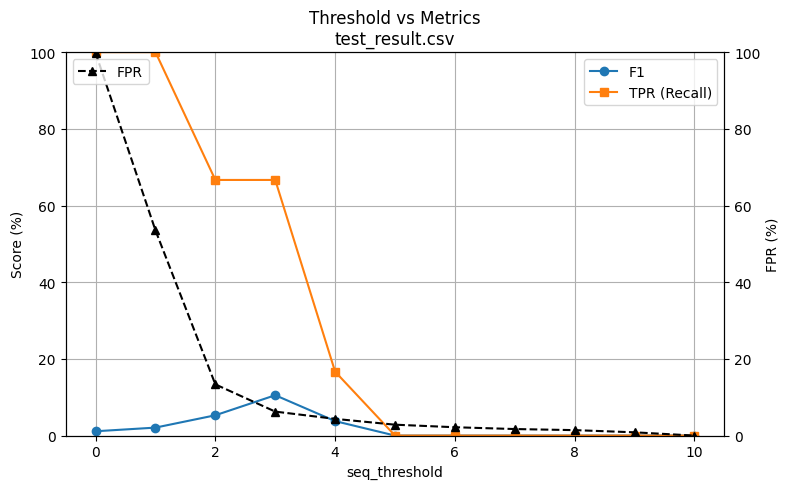

In [ ]:
a.plot_threshold_metrics(Path("../archive/18/test_result.csv")) # LSH

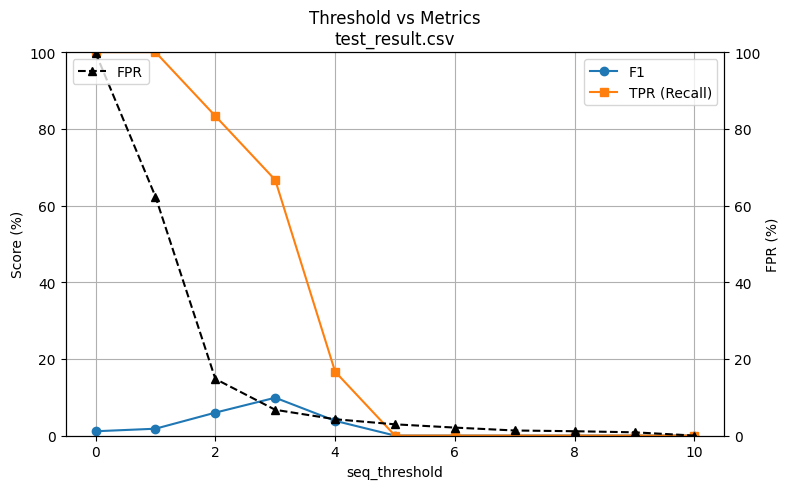

In [ ]:
a.plot_threshold_metrics(Path("../archive/16/test_result.csv")) # no ProcessID

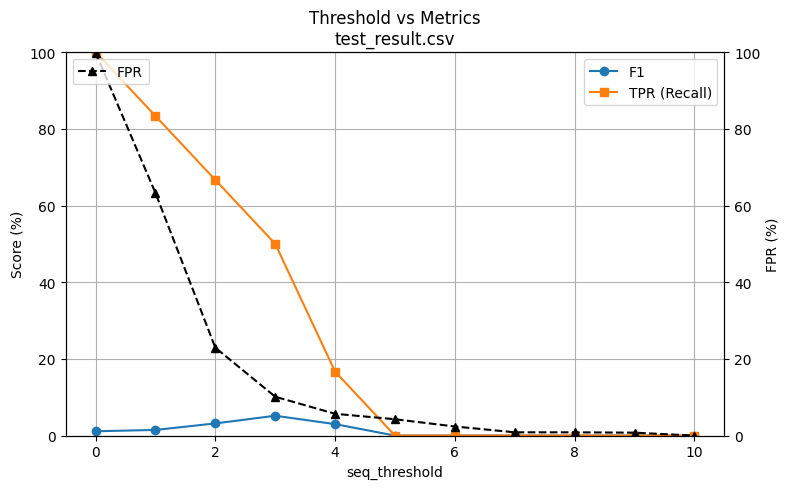

In [ ]:
a.plot_threshold_metrics(Path("../archive/15/test_result.csv")) # ProcessID only

## train(T1105 + T1055) ⇒ test(T1105, T1055)
- プロジェクト名：ex6
- データサイズによるスケーラビリティを検証する

### モデル前データ作成

In [30]:
preprocess.merge_processed_files(
    file_path1=PROCESSED_DIR/"ex1"/"train", # T1105のtrain
    file_path2=PROCESSED_DIR/"ex5"/"train", # T1055のtrain
    output_dir=PROCESSED_DIR/"ex6",
    output_filename="train",  # 結合後のファイル名
    mode="fixed",               # seq_stats.txt用のモード
    window_size=430,            # seq_stats.txt用のウィンドウサイズ
    step_size=200,              # seq_stats.txt用のステップサイズ
)

Merged 4822 lines from train
Merged 6149 lines from train
Total: 10971 lines
Output saved to: ../data/processed/ex6/train
Sequence Length Statistics Report
Generated: 2026-01-19 02:02:57
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: merged]
--------------------------------------------------
  train:
    Count:    10,971
    Avg Len:  430.00
    Min Len:  430
    Max Len:  430
    Std Dev:  0.00


Statistics saved to: ../data/processed/ex6/seq_stats.txt


### 検証

In [ ]:
# train
main.main_cli([
    "train",
    "bert/ex6",           # conf/bert_config_name.yaml
])

In [6]:
# テスト
main.main_cli([
    "test",  # run_mode
    "../outputs/logbert/bert_no_time/ex6/seq_len_512/r_seed_31/weights/ValTotalbest.pth", # 重みファイルまでの相対パス
    "32",   # eval_batchsize
    "cuda:0",     # gpu
    "eval.dataset_dir=../data/processed/ex6/T1007",
])

../outputs/logbert/bert_no_time/ex6/seq_len_512/r_seed_31
cuda:0 cuda:0
Found 11 vocab source files:
  - ../data/processed/ex6/train
  - ../data/processed/ex6/T1007/test_abnormal
  - ../data/processed/ex6/T1007/test_normal
  - ../data/processed/ex6/T1055/test_abnormal
  - ../data/processed/ex6/T1055/test_normal
  - ../data/processed/ex6/T1105/test_abnormal
  - ../data/processed/ex6/T1105/test_normal
  - ../data/processed/ex6/WEB1/test_abnormal
  - ../data/processed/ex6/WEB1/test_normal
  - ../data/processed/ex6/WEB2/test_abnormal
  - ../data/processed/ex6/WEB2/test_normal
Total lines processed: 13636
Building Vocab


100%|██████████| 13636/13636 [00:00<00:00, 17134.11it/s]


VOCAB SIZE: 2113
Updated vocab_size to 2113


100%|██████████| 10/10 [00:00<00:00, 29.83it/s]

Saving test normal results
Saving test abnormal results
[seq_th, FP, TP, TN, FN, Precision, Recall, F1, TPR, FPR]
threshold=0.000['288.0000', '10.0000', '0.0000', '0.0000', '3.3557', '100.0000', '6.4935', '100.0000', '100.0000']
threshold=0.100['288.0000', '10.0000', '0.0000', '0.0000', '3.3557', '100.0000', '6.4935', '100.0000', '100.0000']
threshold=0.200['288.0000', '10.0000', '0.0000', '0.0000', '3.3557', '100.0000', '6.4935', '100.0000', '100.0000']
threshold=0.300['288.0000', '10.0000', '0.0000', '0.0000', '3.3557', '100.0000', '6.4935', '100.0000', '100.0000']
threshold=0.400['288.0000', '10.0000', '0.0000', '0.0000', '3.3557', '100.0000', '6.4935', '100.0000', '100.0000']
threshold=0.500['288.0000', '10.0000', '0.0000', '0.0000', '3.3557', '100.0000', '6.4935', '100.0000', '100.0000']
threshold=0.600['288.0000', '10.0000', '0.0000', '0.0000', '3.3557', '100.0000', '6.4935', '100.0000', '100.0000']
threshold=0.700['288.0000', '10.0000', '0.0000', '0.0000', '3.3557', '100.0000', 

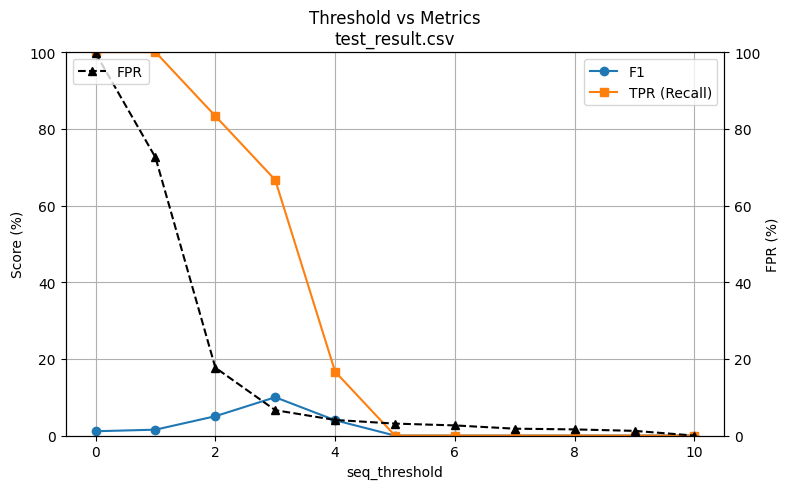

In [5]:
a.plot_threshold_metrics(Path("../outputs/logbert/bert_no_time/ex6/seq_len_512/r_seed_31/test_result.csv"))

### 可視化

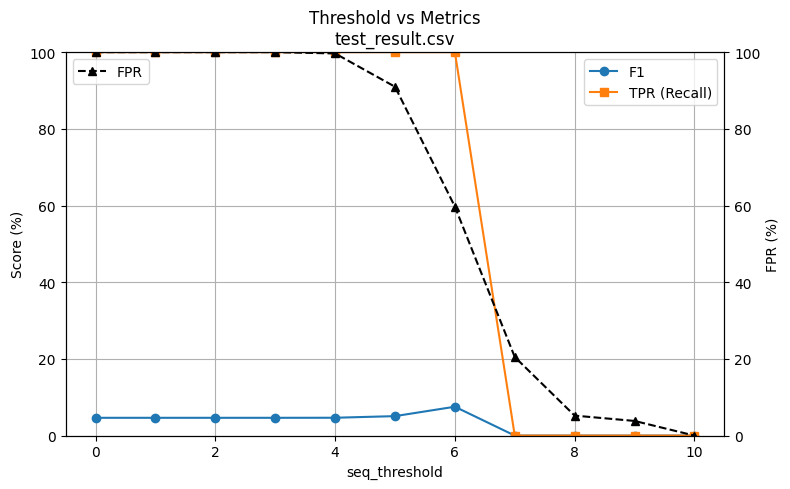

In [13]:
a.plot_threshold_metrics(Path("../archive/19/T1105/test_result.csv"))

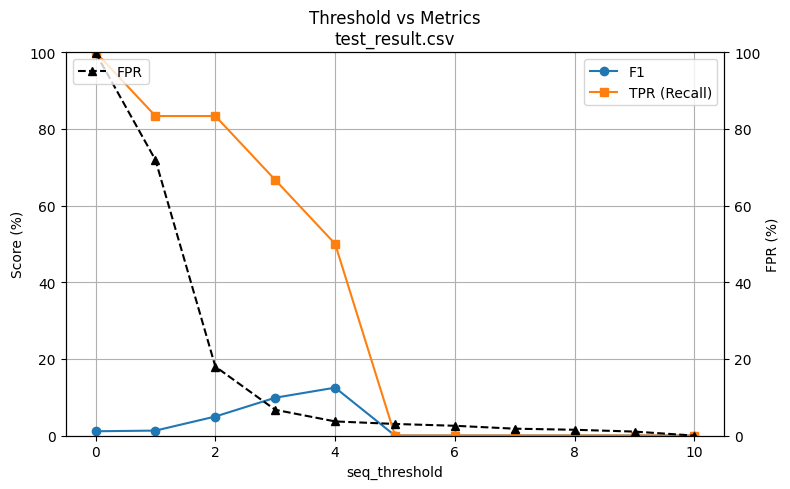

In [14]:
a.plot_threshold_metrics(Path("../archive/19/T1055/test_result.csv"))

# その他

In [7]:
projects = ["T1055"]

for project in projects:
    process_csv(
        input_csv_path=INTERIM_DIR/f'{project}/security2_structured.csv',
        output_csv_path=INTERIM_DIR/f'{project}/security2_structured_unmasked2.csv',
        no_mask_config="no_mask.json",
        new_column_name='EventTemplateUnmasked',
        hash_method="md5",
    )

Loading no_mask config from: no_mask.json
Loading CSV from: ../data/interim/T1055/security2_structured.csv
Total rows: 1448457
Columns: ['EventID', 'Level', 'Correlation_ActivityID', 'Computer', 'Content', 'Provider_Name', 'Opcode', 'Provider_Guid', 'Task', 'Keywords', 'Correlation_RelatedActivityID', 'Execution_ThreadID', 'Security_UserID', 'TimeCreated_SystemTime', 'Version', 'Execution_ProcessID', 'Channel', 'EventRecordID', 'Label', 'EventId', 'EventTemplate']

Processing EventID: 4688, Attributes: ['NewProcessName', 'ParentProcessName', 'MandatoryLabel']
  Found 44395 rows with EventID=4688

Processing EventID: 5156, Attributes: ['Application', 'DestPort', 'Protocol', 'Direction']
  Found 659715 rows with EventID=5156

Processing EventID: 4673, Attributes: ['ObjectServer', 'Service', 'PrivilegeList', 'ProcessName']
  Found 29070 rows with EventID=4673

Processing EventID: 4702, Attributes: ['SubjectDomainName', 'TaskName']
  Found 31864 rows with EventID=4702

Processing EventID: 

In [9]:
preprocess.prepare_model_train_data(
    logdata_filepath = INTERIM_DIR / "T1055/security2_structured_unmasked2.csv",
    output_dir = PROCESSED_DIR / "else",
    train_ratio=0.85,
    features = ["EventTemplateUnmaskedHash_md5", "deltaT"],
    use_columns = ["timestamp", "Label", "EventID", "EventTemplateUnmaskedHash_md5", "deltaT"],
    window_size = 430,
    step_size = 200,
    mode = "fixed", 
)

/home/ubuntu/My_lad/src/preprocess.py:865: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 7241 instances (sliding windows) in this dataset

training size 6149
Sequence Length Statistics Report
Generated: 2026-01-24 02:53:14
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: 0.85]
--------------------------------------------------
  train:
    Count:    6,149
    Avg Len:  6149.00
    Min Len:  6149
    Max Len:  6149
    Std Dev:  0.00


Statistics saved to: ../data/processed/else/seq_stats.txt


In [10]:
preprocess.prepare_model_test_data(
    logdata_filepath = INTERIM_DIR / "T1055/security2_structured_unmasked2.csv",
    output_dir = PROCESSED_DIR / "else",
    train_ratio=0.85,
    features = ["EventTemplateUnmaskedHash_md5", "deltaT"],
    use_columns = ["timestamp", "Label", "EventID", "EventTemplateUnmaskedHash_md5", "deltaT"],
    window_size = 430,
    step_size = 200,
    mode = "fixed", 
)

/home/ubuntu/My_lad/src/preprocess.py:945: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 7241 instances (sliding windows) in this dataset

test normal size 1086
test abnormal size 6
Sequence Length Statistics Report
Generated: 2026-01-24 02:53:37
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: 0.85]
--------------------------------------------------
  test_normal:
    Count:    1,086
    Avg Len:  1086.00
    Min Len:  1086
    Max Len:  1086
    Std Dev:  0.00
  test_abnormal:
    Count:    6
    Avg Len:  6.00
    Min Len:  6
    Max Len:  6
    Std Dev:  0.00


Statistics saved to: ../data/processed/else/seq_stats.txt


In [ ]:
# train
main.main_cli([
    "train",
    "bert/else",           # conf/bert_config_name.yaml
])

In [13]:
# テスト
main.main_cli([
    "test",  # run_mode
    "../outputs/logbert/bert_no_time/else/seq_len_512/r_seed_31/weights/ValTotalbest.pth", # 重みファイルまでの相対パス
    "32",   # eval_batchsize
    "cuda:0",     # gpu
    "eval.dataset_dir=../data/processed/else",
])

../outputs/logbert/bert_no_time/else/seq_len_512/r_seed_31
cuda:0 cuda:0
Found 3 vocab source files:
  - ../data/processed/else/test_abnormal
  - ../data/processed/else/test_normal
  - ../data/processed/else/train
Total lines processed: 7241
Building Vocab


100%|██████████| 7241/7241 [00:00<00:00, 19736.57it/s]


VOCAB SIZE: 1530
Updated vocab_size to 1530


100%|██████████| 6/6 [00:00<00:00, 11.42it/s]

Saving test normal results
Saving test abnormal results
[seq_th, FP, TP, TN, FN, Precision, Recall, F1, TPR, FPR]
threshold=0.000['1054.0000', '6.0000', '2.0000', '0.0000', '0.5660', '100.0000', '1.1257', '100.0000', '99.8106']
threshold=0.100['658.0000', '5.0000', '398.0000', '1.0000', '0.7541', '83.3333', '1.4948', '83.3333', '62.3106']
threshold=0.200['148.0000', '5.0000', '908.0000', '1.0000', '3.2680', '83.3333', '6.2893', '83.3333', '14.0152']
threshold=0.300['70.0000', '4.0000', '986.0000', '2.0000', '5.4054', '66.6667', '10.0000', '66.6667', '6.6288']
threshold=0.400['45.0000', '1.0000', '1011.0000', '5.0000', '2.1739', '16.6667', '3.8462', '16.6667', '4.2614']
threshold=0.500['30.0000', '0.0000', '1026.0000', '6.0000', '0.0000', '0.0000', '0.0000', '0.0000', '2.8409']
threshold=0.600['23.0000', '0.0000', '1033.0000', '6.0000', '0.0000', '0.0000', '0.0000', '0.0000', '2.1780']
threshold=0.700['15.0000', '0.0000', '1041.0000', '6.0000', '0.0000', '0.0000', '0.0000', '0.0000', '1

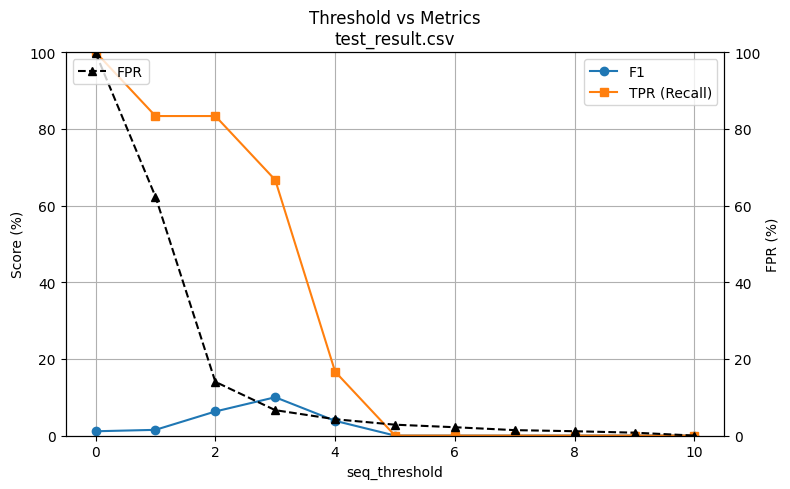

In [14]:
a.plot_threshold_metrics(Path("../outputs/logbert/bert_no_time/else/seq_len_512/r_seed_31/test_result.csv"))